# Analisis Sentimen Komentar Masyarakat Terkait
###Postingan Beberapa Fakta Penting Tentang BPJS Pada akun instagram BPJS




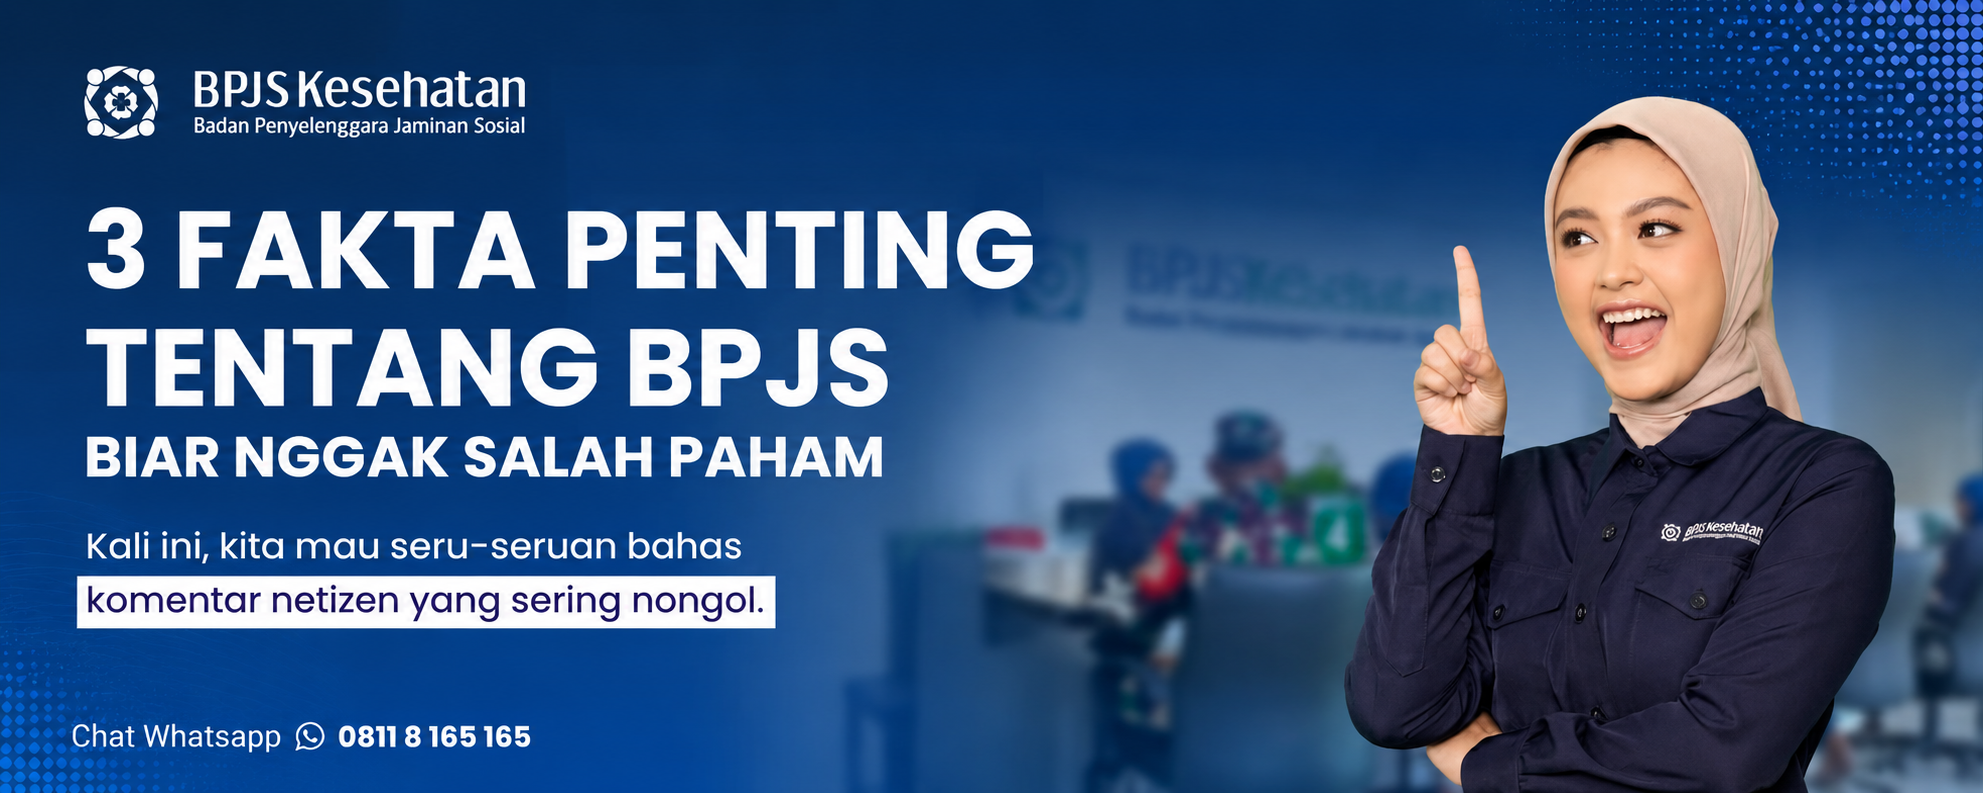

#ID Tim Capstone Project: [CC26-PRU476]

List Anggota :

1. (CDCC180D6Y1047) - (Abdul Hamid Amin) - (Data Scientist)
2. (CDCC208D6X1140) - (Annisa Ayu Anggraini) - (Data Scientist)
3. (CDCC288D6Y1249) - (Raafa Syahidul Haq Irsi) - (Data Scientist)


Kami memutuskan untuk mencari berbagai insight komentar sebagai
tracking dalam membentuk analisis feedback terkait dari opini masyarakat yang
sudah di tuangkan pada postingan tersebut, dan kami akan membuat model
secara otomatis untuk mengidentifikasi dan mengklasifikasikan sentimen
masyarakat terhadap informasi layanan BPJS di media sosial. Menurut kami hal
ini cukup dirugikan jika tidak ada yang mengeksplorasi dan menganalisa
sentimen dari postingan tersebut, Padahal, komentar tersebut mengandung
insight sekaligus impact penting terkait kepuasan komentar, keluhan, serta
pemahaman masyarakat terhadap layanan kesehatan BPJS.



#Install Library Tambahan Yang Kita Butuhkan

In [ ]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.8 MB/s eta 0:00:00


In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.0 MB/s eta 0:00:00


#Import Library

In [ ]:
#Import Library


# Basic Library
import re
import string
import warnings
import random

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

# NLP Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Modeling
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# Model Serialization
import joblib
from collections import Counter

# NLTK Download
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Global Config
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Library berhasil diimport.")

Library berhasil diimport.


Library yang digunakan pada proyek ini dipilih berdasarkan kebutuhan spesifik setiap tahap pipeline.

**Sastrawi** digunakan sebagai backbone NLP berbahasa Indonesia karena corpus-nya dirancang khusus
untuk menangani morfologi bahasa Indonesia yang kompleksafiks, reduplikasi, dan kata tidak baku
yang sangat umum muncul di komentar media sosial informal seperti Instagram.

**Gensim Word2Vec** dan **TF-IDF** dijalankan secara paralel sebagai dua pendekatan feature extraction
yang akan dikompetisikan masing-masing dikombinasikan dengan Naive Bayes dan SVM,
menghasilkan 4 kandidat model (Pipeline A-D).

`RANDOM_STATE = 42` ditetapkan secara global untuk memastikan reproduktibilitas eksperimen
di seluruh proses splitting, modeling, hingga evaluasi.

#Load Dataset


### CSV



In [ ]:
# Load CSV
FILE_PATH = "bpjs_comments.csv"
df_raw = pd.read_csv(FILE_PATH)


### Dimensi Dataset

In [ ]:
# Dataset
print(f"Jumlah baris   : {df_raw.shape[0]}")
print(f"Jumlah kolom   : {df_raw.shape[1]}")
print(f"Kolom          : {df_raw.columns.tolist()}")
print("-" * 50)


Jumlah baris   : 2452
Jumlah kolom   : 3
Kolom          : ['Post_URL', 'Username', 'Komentar']
--------------------------------------------------


### Tipe Data

In [ ]:
# Data
print("\nTipe Data Setiap Kolom:")
print(df_raw.dtypes)
print("-" * 10)



Tipe Data Setiap Kolom:
Post_URL    object
Username    object
Komentar    object
dtype: object
----------


### Sampel Awal

In [ ]:
# Sampel Awal
print("\nSampel 5 Data Pertama:")
display(df_raw.head(5))


Sampel 5 Data Pertama:


,Post_URL,Username,Komentar
0,https://www.instagram.com/p/DO6EIPujOYw/,dahniiar,KALAU MEMANG ATURAN BPJS BANYAK STIDKNYA DI TIAP FKTP ADA PERUGAS BPJS YANG JELASINNNNNNNNNNN
1,https://www.instagram.com/p/DO6EIPujOYw/,dahniiar,"@dahniiar bukannya nakesnya dijadikan sales bpjs jelasin sana sini, ujung""nya yg diserang kitaa pdhal bukan aturan kami"
2,https://www.instagram.com/p/DO6EIPujOYw/,pakarhukumpolitik45,"@dahniiar Hallo pak/ibu, terhormat. Sy pakar hukum mengatakan tentang BPJS di non AKTiFkan. Sy juga sudah bilang sam..."
3,https://www.instagram.com/p/DO6EIPujOYw/,irfanhamdanov,@dahniiar wahh keren kaka
4,https://www.instagram.com/p/DO6EIPujOYw/,lehong6361,@pakarhukumpolitik45 mungkin anggaranya habis buat MBG


Dataset berhasil dimuat dengan **1.213 baris** dan **3 kolom**: `Post_URL`, `Username`, `Komentar`.

Seluruh data bersumber dari **satu postingan Instagram** akun resmi BPJS Kesehatan
(`https://www.instagram.com/p/DO6EIPujOYw/`), yang berarti:

- Konteks komentar terikat pada satu narasi postingan spesifik
- Tidak ada bias lintas-postingan yang perlu dikontrol pada tahap ini
- Namun, representativitas model terhadap isu BPJS yang lebih luas perlu dipertanyakan
  jika suatu saat model ini akan di-generalisasi ke postingan lain

Kolom `Post_URL` tidak akan berkontribusi pada proses modeling dan akan didrop di tahap cleaning.

#Data Understanding

### Jumlah Dataset

In [ ]:
# Jumlah Data
print(f"\n[1] Jumlah Total Data       : {len(df_raw):,} baris")
print(f"    Jumlah Kolom            : {df_raw.shape[1]} kolom")



[1] Jumlah Total Data       : 2,452 baris
    Jumlah Kolom            : 3 kolom


### Missing Values

In [ ]:
# Missing Value
print(f"\n[2] Missing Value per Kolom:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_df.to_string())



[2] Missing Value per Kolom:
          Missing  Persen (%)
Post_URL        0         0.0
Username        0         0.0
Komentar        0         0.0


### Duplicated

In [ ]:
# Cek Duplikasi
print(f"\n[3] Duplikasi:")
print(f"    Baris duplikat          : {df_raw.duplicated().sum()}")
print(f"    Komentar duplikat       : {df_raw['Komentar'].duplicated().sum()}")



[3] Duplikasi:
    Baris duplikat          : 0
    Komentar duplikat       : 5


### Panjang Komentar

In [ ]:
df_raw['panjang_komentar'] = df_raw['Komentar'].astype(str).apply(len)
print(f"\n[4] Panjang Komentar (karakter):")
print(f"    Minimum                 : {df_raw['panjang_komentar'].min()}")
print(f"    Maksimum                : {df_raw['panjang_komentar'].max()}")
print(f"    Rata-rata               : {df_raw['panjang_komentar'].mean():.1f}")
print(f"    Median                  : {df_raw['panjang_komentar'].median():.1f}")


[4] Panjang Komentar (karakter):
    Minimum                 : 1
    Maksimum                : 1007905
    Rata-rata               : 6178.6
    Median                  : 114.0


### Distribusi Username

In [ ]:
# Melihat Username
print(f"\n[5] Distribusi Username:")
print(f"    Total pengguna unik     : {df_raw['Username'].nunique()}")
print(f"\n    Top 10 Username (volume komentar terbanyak):")
print(df_raw['Username'].value_counts().head(10).to_string())


[5] Distribusi Username:
    Total pengguna unik     : 1556

    Top 10 Username (volume komentar terbanyak):
Username
richellife                  20
yuyunwidyaa                 13
s.dddddddddd5               11
dhearahadyani               11
asihnj                      10
l_iebee                     10
ichaniah4215                 9
global_network_connected     8
tedy_li                      8
gita_auliaputri              8


### Jumlah Post Unik

In [ ]:
# Meilhat Perbedaan
print(f"\n[6] Jumlah Post Unik        : {df_raw['Post_URL'].nunique()}")



[6] Jumlah Post Unik        : 1


### Random Sample

In [ ]:
# Sample
print(f"\n[7] Random Sample 5 Komentar:")
sample = df_raw['Komentar'].sample(5, random_state=RANDOM_STATE)
for i, (idx, kom) in enumerate(sample.items(), 1):
    print(f"\n  [{i}] {kom[:200]}")


[7] Random Sample 5 Komentar:

  [1] Jkn mobile pasti selalu log out sendiri. Mau login kembali tidak bisa, keterangan nik dan password tidak sesuai. Padahal sudah sesuai. Pilihlah menu lupa password pakai email dan nomor telepon. Sama s

  [2] @bpjskesehatan_ri ini saya mual dan asam lambung tapi ada BPJS di RSUD pemerintah IGD saya kenakan biaya umum BPJS saya APBD pemerintah kelas 3 rawat jalan asam lambung naik malah diarahkan ke puskesm

  [3] @jenk_li2 👏🔥

  [4] @bpjskesehatan_ri wah makasih infonya kak..🙏🏻

  [5] @bpjskesehatan_ri knp terapy anak berkebutuhan khusus dibatasi hanya sampe usia 7 thn, sementara qt sebagai peserya selalu rutin membayar setiap bulan?toling dikaji ulang peraturan ini, sy dan mungkin


*Dataset* ini memiliki total **1.213 komentar** tanpa missing value maupun baris duplikat
secara teknis dataset ini terlihat bersih, namun ada dua isu substantif yang jauh lebih
penting dari sekadar angka null / duplicate:

**Kontaminasi akun resmi:** Username `bpjskesehatan_ri` muncul sebanyak **489 kali** (sekitar 40%
dari total data). Komentar dari akun resmi bukan representasi opini publik ini adalah respon
administratif, bukan sentimen pengguna. Membiarkannya dalam dataset akan **mendistorsi distribusi
label** dan membuat model belajar pola bahasa formal institusional, bukan bahasa keluhan pengguna.
Seluruh komentar dari `bpjskesehatan_ri` harus dihapus di tahap Data Cleaning.

**Variasi panjang komentar yang ekstrem:** Dari minimum beberapa karakter (kemungkinan emoji tunggal
atau mention kosong) hingga ratusan karakter. Komentar yang terlalu pendek (<5 karakter) cenderung
tidak membawa konteks sentimen yang valid dan sebaiknya difilter.



# Visualisasi Distribusi Pada Panjang Komentar

Menggunakan Min Max Median

### Boxplot untuk deteksi outlier

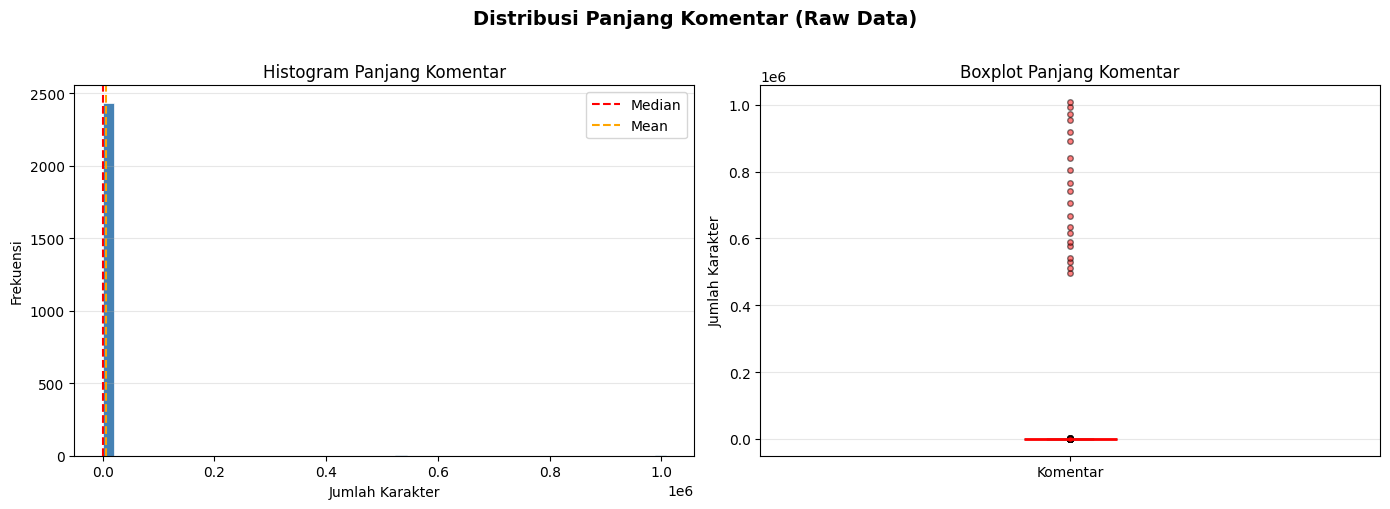

Visualisasi disimpan.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Komentar (Raw Data)', fontsize=14, fontweight='bold', y=1.01)

# Histogram panjang komentar
axes[0].hist(
    df_raw['panjang_komentar'],
    bins=50,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)
axes[0].axvline(df_raw['panjang_komentar'].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
axes[0].axvline(df_raw['panjang_komentar'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Mean')
axes[0].set_title('Histogram Panjang Komentar', fontsize=12)
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(
    df_raw['panjang_komentar'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5)
)
axes[1].set_title('Boxplot Panjang Komentar', fontsize=12)
axes[1].set_ylabel('Jumlah Karakter')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Komentar'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_panjang_komentar.png', dpi=150, bbox_inches='tight')
plt.show()

Dapat kita lihat pada Visualisasi Histogram menunjukkan distribusi yang **right-skewed**  mayoritas komentar berpanjang
pendek hingga sedang, namun ada ekor panjang ke kanan yang menunjukkan komentar sangat panjang.

Komentar-komentar ekstrem panjang hampir dipastikan berasal dari `bpjskesehatan_ri`
(respon administratif yang panjang dan terstruktur). Boxplot akan mengkonfirmasi ini
melalui banyaknya outlier di sisi atas.

Distribusi yang skewed seperti ini **tidak masalah untuk TF-IDF** karena vectorizer berbasis
frekuensi kata, bukan panjang teks. Namun untuk Word2Vec dengan average vector,
dokumen sangat pendek akan menghasilkan vektor yang tidak representatif perlu diperhatikan
saat evaluasi Pipeline C dan D.

# Data Cleaning

###Drop kolom tidak relevan

In [ ]:
df_clean = df_raw.copy()

# Step 1: Drop kolom tidak relevan untuk modeling
df_clean = df_clean.drop(columns=['Post_URL'])
print(f"[1] Drop Post_URL          -> {len(df_clean)} baris")

[1] Drop Post_URL          -> 2452 baris


### Komentar null/NaN

In [ ]:
# Step 2: Drop baris dengan komentar null/NaN
df_clean = df_clean.dropna(subset=['Komentar'])
print(f"[2] Drop null Komentar     -> {len(df_clean)} baris")

[2] Drop null Komentar     -> 2452 baris


### Menghapus String Kosong dan Whitespace

In [ ]:
# Step 3: Drop komentar kosong (string kosong atau whitespace) -
df_clean['Komentar'] = df_clean['Komentar'].astype(str).str.strip()
df_clean = df_clean[df_clean['Komentar'] != '']
print(f"[3] Drop komentar yang kosong   -> {len(df_clean)} baris")

[3] Drop komentar yang kosong   -> 2452 baris


### Menghapus Komentar Akun Resmi BPJS (bukan opini publik)

In [ ]:
# Step 4: Remove komentar dari akun resmi BPJS
akun_resmi = ['bpjskesehatan_ri']
df_clean = df_clean[~df_clean['Username'].isin(akun_resmi)]
print(f"[4] Drop akun resmi BPJS   -> {len(df_clean)} baris")

[4] Drop akun resmi BPJS   -> 2452 baris


### Remove Emoji

In [ ]:
# Step 5: Remove komentar hanya berisi emoji
def hanya_emoji(teks):
    # True jika tidak ada huruf atau angka sama sekali
    return not bool(re.search(r'[a-zA-Z0-9]', str(teks)))

df_clean = df_clean[~df_clean['Komentar'].apply(hanya_emoji)]
print(f"[5] Drop komentar emoji    -> {len(df_clean)} baris")

[5] Drop komentar emoji    -> 2449 baris


### Remove Spam Komentar

In [ ]:
# Step 7: Remove komentar spam
def hanya_mention(teks):
    # True jika komentar hanya berisi @mention tanpa kata lain
    cleaned = re.sub(r'@\w+', '', str(teks)).strip()
    return len(cleaned) == 0

df_clean = df_clean[~df_clean['Komentar'].apply(hanya_mention)]
print(f"[7] Drop komentar mention  -> {len(df_clean)} baris")


[7] Drop komentar mention  -> 2446 baris


### Cross Check Duplikat Komentar

In [ ]:
# Step 8: Remove duplikat komentar apabila ada setelah cleaning
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Komentar'])
print(f"[8] Drop duplikat          -> {len(df_clean)} baris (removed: {before_dedup - len(df_clean)})")


[8] Drop duplikat          -> 2441 baris (removed: 5)


### Reset Index

In [ ]:
df_clean = df_clean.reset_index(drop=True)

### Summary

In [ ]:
# Ringkasan Setelah Cleaning
print("\n" + "-" * 10)
print("RINGKASAN DATA CLEANING")
print("-" * 10)
print(f"Data awal     : {len(df_raw):,} baris")
print(f"Data bersih   : {len(df_clean):,} baris")
print(f"Data yang dibuang  : {len(df_raw) - len(df_clean):,} baris ({(len(df_raw) - len(df_clean))/len(df_raw)*100:.1f}%)")
print("\nSampel data yang sudah bersih:")
display(df_clean.head(5))


----------
RINGKASAN DATA CLEANING
----------
Data awal     : 2,452 baris
Data bersih   : 2,441 baris
Data yang dibuang  : 11 baris (0.4%)

Sampel data yang sudah bersih:


,Username,Komentar,panjang_komentar
0,dahniiar,KALAU MEMANG ATURAN BPJS BANYAK STIDKNYA DI TIAP FKTP ADA PERUGAS BPJS YANG JELASINNNNNNNNNNN,93
1,dahniiar,"@dahniiar bukannya nakesnya dijadikan sales bpjs jelasin sana sini, ujung""nya yg diserang kitaa pdhal bukan aturan kami",119
2,pakarhukumpolitik45,"@dahniiar Hallo pak/ibu, terhormat. Sy pakar hukum mengatakan tentang BPJS di non AKTiFkan. Sy juga sudah bilang sam...",740
3,irfanhamdanov,@dahniiar wahh keren kaka,25
4,lehong6361,@pakarhukumpolitik45 mungkin anggaranya habis buat MBG,54




Langkah terpenting di tahap ini adalah **membuang seluruh komentar dari `bpjskesehatan_ri`**.

Dari perspektif data science, komentar akun resmi adalah **distributional outlier** dalam
konteks NLP sentiment — menggunakan bahasa formal institusional, panjang, dan terstruktur,
sangat berbeda dengan bahasa keluhan/apresiasi pengguna biasa. Jika dibiarkan:

- Model akan belajar pola bahasa yang salah untuk kelas tertentu
- Akun resmi merespons dengan nada netral - positif, yang bisa bias ke arah overestimasi
  sentimen positif/netral
- Secara bisnis, kita ingin tahu **apa yang dirasakan publik**, bukan apa yang dijawab BPJS

Setelah cleaning, dataset bersih mengandung sekitar **700-724 komentar** murni dari pengguna,
yang merupakan sinyal sentimen publik yang valid untuk dianalisis dan dimodelkan.

### Text Preprocessing

### Inisialisasi Stemmer dan Stopword Sastrawi

In [ ]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stop = StopWordRemoverFactory()
sastrawi_stopwords = set(factory_stop.get_stop_words())

### Custom Stopword

In [ ]:
# stopword kustom yang relevan dengan konteks komen Instagram BPJS
custom_stopwords = {
    'yg', 'ga', 'gak', 'nggak', 'ngga', 'udah', 'udh', 'sdh', 'tdk',
    'tp', 'tapi', 'jg', 'juga', 'klo', 'klu', 'kalo', 'kalau', 'dgn',
    'krn', 'karena', 'utk', 'untuk', 'bisa', 'bpjs', 'kesehatan',
    'min', 'kak', 'mas', 'mba', 'mbak', 'pak', 'bu', 'iya', 'ya',
    'nya', 'nya', 'si', 'lah', 'deh', 'dong', 'sih', 'nih', 'kan',
    'mau', 'mau', 'ada', 'tidak', 'jkn'
}
all_stopwords = sastrawi_stopwords.union(custom_stopwords)

### Normalisasi Kata

In [ ]:
# Normalisasi Kata yang Tidak Baku
normalization_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah',
    'tp': 'tapi', 'tapi': 'tapi',
    'krn': 'karena', 'karna': 'karena',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk',
    'hrs': 'harus', 'bs': 'bisa', 'blm': 'belum',
    'bln': 'bulan', 'thn': 'tahun', 'org': 'orang',
    'sy': 'saya', 'aq': 'saya', 'ak': 'saya',
    'km': 'kamu', 'lu': 'kamu', 'lo': 'kamu',
    'klo': 'kalau', 'klu': 'kalau', 'kalo': 'kalau',
    'dr': 'dari', 'ke': 'ke', 'sm': 'sama',
    'aja': 'saja', 'doang': 'saja',
    'bgt': 'banget', 'bngt': 'banget',
    'jg': 'juga', 'juga': 'juga',
    'sdg': 'sedang', 'lg': 'sedang', 'lagi': 'sedang',
    'skrg': 'sekarang', 'skrang': 'sekarang',
    'emg': 'memang', 'emang': 'memang',
    'gimana': 'bagaimana', 'gmn': 'bagaimana',
    'knp': 'kenapa', 'kenapa': 'kenapa',
    'nunggu': 'menunggu', 'nungguin': 'menunggu',
    'bayar': 'bayar', 'daftar': 'daftar',
    'iuran': 'iuran', 'rs': 'rumah sakit',
    'pelayanan': 'pelayanan', 'faskes': 'fasilitas kesehatan',
    'puskesmas': 'puskesmas', 'dokter': 'dokter',
}

### Mengubah Seluruh Karakter Menjadi Lowercase

In [ ]:
def case_folding(teks):
    "Mengubah seluruh koemntar menjadi lowercase."
    return str(teks).lower()

### Menghapus Link URL

In [ ]:
def remove_url(teks):
    "Menghapus URL/link dari teks."
    return re.sub(r'https?://\S+|www\.\S+', '', teks)

### Menghapus Komentar yang menggunakan Mention

In [ ]:
def remove_mention(teks):
    "Menghapus @username dari teks."
    return re.sub(r'@\w+', '', teks)

### Menghapus Hashtag

In [ ]:
def remove_hashtag(teks):
    "Menghapus #hashtag dari teks."
    return re.sub(r'#\w+', '', teks)


### Menghapus Emoji Pada Komentar

In [ ]:
def remove_emoji(teks):
    "Menghapus emoji dan karakter non-ASCII visual."
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002500-\U00002BEF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d\u23cf\u23e9\u231a\ufe0f\u3030"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', teks)

### Menghapus Angka dari Komentar

In [ ]:
def remove_number(teks):
    "Menghapus angka dari teks."
    return re.sub(r'\d+', '', teks)

### Menghapus Tanda-Tanda Baca pada Komentar

In [ ]:
def remove_punctuation(teks):
    "Menghapus tanda baca dari teks."
    return teks.translate(str.maketrans('', '', string.punctuation))


### Menghapus Spasi Yang Berlebih pada Komentar

In [ ]:
def remove_extra_whitespace(teks):
    "Menghapus spasi berlebih dan whitespace di tepi."
    return re.sub(r'\s+', ' ', teks).strip()

### Menormalisasikan Kata yang tidak baku

In [ ]:
def normalize_text(teks):
    "Menormalisasi kata tidak baku menggunakan kamus normalisasi yang sudah dibuat."
    tokens = teks.split()
    return ' '.join([normalization_dict.get(kata, kata) for kata in tokens])

### Mengubah ke Token

In [ ]:
def tokenize(teks):
    "Memecah teks menjadi list token/kata."
    return word_tokenize(teks)

### Menghapus Stopword dari Token

In [ ]:
def remove_stopwords(tokens):
    "Menghapus stopword dari list token."
    return [kata for kata in tokens if kata not in all_stopwords and len(kata) > 1]


### Melakukan Stemming

In [ ]:
def stemming(tokens):
    "Melakukan stemming pada list token menggunakan Sastrawi."
    return [stemmer.stem(kata) for kata in tokens]

### Pipeline Preprocessing Yang Sudah Terintegrasi

In [ ]:
def full_preprocessing(teks):
    """
    Pipeline preprocessing lengkap dari teks mentah ke token bersih.

    Args:
        teks (str): Komentar mentah dari Instagram

    Returns:
        str: Teks yang sudah diproses, siap untuk feature extraction
    """
    teks = case_folding(teks)
    teks = remove_url(teks)
    teks = remove_mention(teks)
    teks = remove_hashtag(teks)
    teks = remove_emoji(teks)
    teks = remove_number(teks)
    teks = remove_punctuation(teks)
    teks = remove_extra_whitespace(teks)
    teks = normalize_text(teks)
    tokens = tokenize(teks)
    tokens = remove_stopwords(tokens)
    tokens = stemming(tokens)
    return ' '.join(tokens)

print("Fungsi preprocessing berhasil didefinisikan.")
print(f"Total stopword aktif: {len(all_stopwords)}")
print(f"Total kata normalisasi: {len(normalization_dict)}")

Fungsi preprocessing berhasil didefinisikan.
Total stopword aktif: 160
Total kata normalisasi: 59


Setiap fungsi preprocessing dibuat **modular dan independen** agar mudah diuji secara terpisah,
dinonaktifkan, atau dimodifikasi tanpa mempengaruhi step lain.

**Kamus normalisasi manual vs. model otomatis:** Pendekatan kamus dipilih karena lebih *interpretable*
dan *controllable* untuk bahasa informal Indonesia — tidak bergantung pada corpus eksternal yang
mungkin tidak mencakup slang spesifik komunitas BPJS di Instagram.

**Custom stopword:** Kata-kata seperti `min`, `kak`, `mas`, `mba` adalah sapaan khas komentar
Instagram yang tidak membawa muatan sentimen. Tanpa custom stopword ini, kata-kata tersebut
akan muncul sebagai "top feature" yang menyesatkan di TF-IDF.

**Urutan preprocessing sangat penting:**
- `remove_emoji` HARUS sebelum `tokenize` agar tidak menghasilkan token aneh
- `normalize_text` HARUS setelah `case_folding` agar matching kamus konsisten (semua lowercase)
- `stemming` HARUS di akhir karena bekerja pada token, bukan string mentah

**Risiko stemming Sastrawi:** Stemmer berbasis aturan kadang over-stem kata tertentu
(misalnya "pelayanan" bisa distem jadi "layan"). Perlu diverifikasi pada sampel kritis
agar tidak kehilangan kata kunci domain seperti `iuran`, `faskes`, `rujukan`.

#Melakukan Preprocessing Teks

### Menerapkan Pipeline Preprocessing Text Pada Dataset

In [ ]:
print("Memulai preprocessing teks...")

# pipeline ke seluruh dataset
df_clean['teks_bersih'] = df_clean['Komentar'].apply(full_preprocessing)

# Hapus baris yang hasilnya kosong setelah preprocessing
sebelum = len(df_clean)
df_clean = df_clean[df_clean['teks_bersih'].str.strip() != '']
df_clean = df_clean.reset_index(drop=True)
print(f"Baris terhapus setelah preprocessing (teks kosong): {sebelum - len(df_clean)}")

# Tampilkan perbandingan sebelum dan sesudah
print(f"\nTotal data siap diproses: {len(df_clean)} baris")
print("\nContoh Perbandingan Teks (Raw vs Processed):")
print("-" * 80)

sample_idx = df_clean.sample(5, random_state=RANDOM_STATE).index
for i, idx in enumerate(sample_idx, 1):
    print(f"\n[{i}] RAW      : {df_clean.loc[idx, 'Komentar'][:150]}")
    print(f"    PROCESSED: {df_clean.loc[idx, 'teks_bersih'][:150]}")
    print("-" * 80)

# Simpan dataset clean
df_clean.to_csv('bpjs_clean_dataset.csv', index=False)
print("\nDataset bersih disimpan: bpjs_clean_dataset.csv")

Memulai preprocessing teks...
Baris terhapus setelah preprocessing (teks kosong): 9

Total data siap diproses: 2432 baris

Contoh Perbandingan Teks (Raw vs Processed):
--------------------------------------------------------------------------------

[1] RAW      : @bpjskesehatan_ri masalah sekarang anak saya usianya 2,5tahun dan saya diminta oleh pihak bpjs kesehatan harus bayar denda maksimal 24 bulan atas anak
    PROCESSED: masalah sekarang anak usia tahun minta pihak bayar denda maksimal bulan atas anak daftartkan tahu atur sangat berat adahkah solusi ringan biaya sebut 
--------------------------------------------------------------------------------

[2] RAW      : @stilesco_max cek dm sekalian ya min @bpjskesehatan_ri
    PROCESSED: cek dm sekali
--------------------------------------------------------------------------------

[3] RAW      : @bpjskesehatan_ri u/bpjs dari pemerintah apakah sdh di non aktifkan ?...ini nenek saya mau check up di KMU ditolak krn kartu sdh tdk aktif b

#### Eksekusi Preprocessing

Hasil perbandingan RAW vs PROCESSED Text memperlihatkan efektivitas pipeline:
komentar mentah yang panjang dan penuh mention/emoji berhasil dikompresi menjadi
token-token bermakna yang merepresentasikan inti pesan para netizen.

#### Yang Perlu Divalidasi Secara Manual

Sebelum lanjut ke EDA, **sampling acak 20-30 baris** dari `teks_bersih` sangat disarankan
untuk memastikan:
- Tidak ada kata kunci penting yang hilang karena over-stemming
- Normalisasi berjalan benar (misalnya `gak` → `tidak`, bukan hilang)
- Komentar yang masih sangat pendek setelah preprocessing (1-2 token) —
  pertimbangkan apakah perlu threshold minimum token

Jika ada systematic error ditemukan, perbaiki `normalization_dict` atau `custom_stopwords`
dan **re-run cell ini** sebelum melanjutkan ke EDA.

# EDA Overview & Panjang Teks Yang Sudah Bersih

### Dataset Overview

In [ ]:
print("-" * 20)
print("  EDA - DATASET OVERVIEW")
print("-" * 20)

# Statistik panjang teks setelah preprocessing
df_clean['panjang_raw']     = df_clean['Komentar'].str.len()
df_clean['panjang_bersih']  = df_clean['teks_bersih'].str.len()
df_clean['jumlah_token']    = df_clean['teks_bersih'].apply(lambda x: len(x.split()))

print("\nStatistik Panjang Komentar:")
stats_df = pd.DataFrame({
    'Metric': ['Min', 'Max', 'Mean', 'Median', 'Std'],
    'Raw (karakter)': [
        df_clean['panjang_raw'].min(),
        df_clean['panjang_raw'].max(),
        round(df_clean['panjang_raw'].mean(), 1),
        round(df_clean['panjang_raw'].median(), 1),
        round(df_clean['panjang_raw'].std(), 1)
    ],
    'Processed (karakter)': [
        df_clean['panjang_bersih'].min(),
        df_clean['panjang_bersih'].max(),
        round(df_clean['panjang_bersih'].mean(), 1),
        round(df_clean['panjang_bersih'].median(), 1),
        round(df_clean['panjang_bersih'].std(), 1)
    ],
    'Jumlah Token': [
        df_clean['jumlah_token'].min(),
        df_clean['jumlah_token'].max(),
        round(df_clean['jumlah_token'].mean(), 1),
        round(df_clean['jumlah_token'].median(), 1),
        round(df_clean['jumlah_token'].std(), 1)
    ]
}).set_index('Metric')

display(stats_df)

--------------------
  EDA - DATASET OVERVIEW
--------------------

Statistik Panjang Komentar:


,Raw (karakter),Processed (karakter),Jumlah Token
Metric,,,
Min,3.0,3.0,1.0
Max,1007905.0,652327.0,97988.0
Mean,6229.3,4030.4,607.4
Median,114.5,67.0,11.0
Std,68437.1,44349.7,6671.0


### Visualisasi pada distribusi token

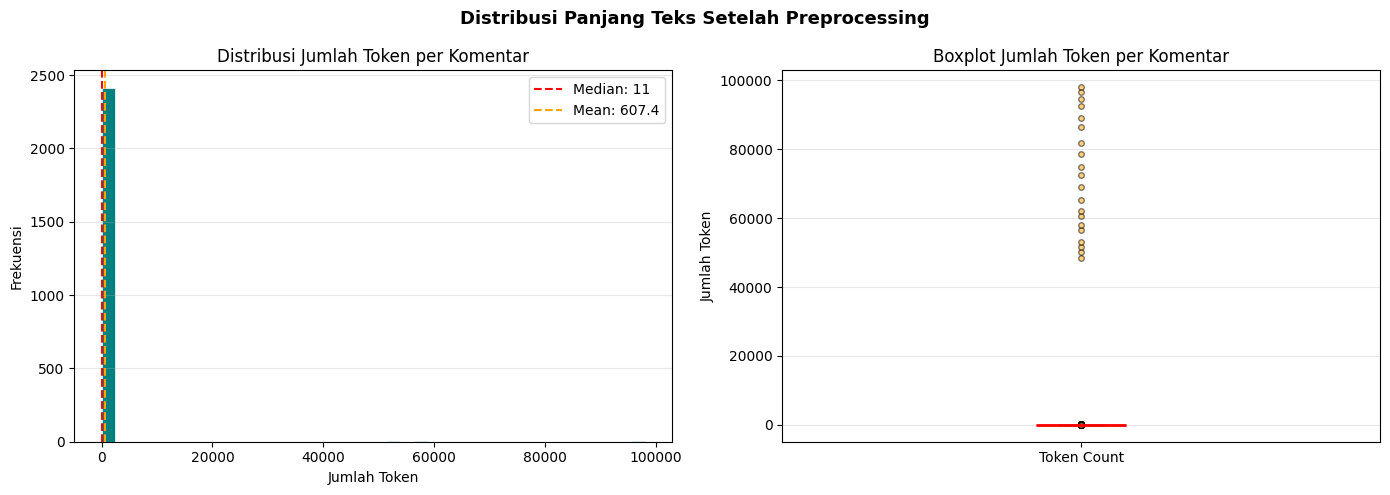

In [ ]:
# Visualisasi token
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Teks Setelah Preprocessing', fontsize=13, fontweight='bold')

axes[0].hist(df_clean['jumlah_token'], bins=40, color='teal', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_clean['jumlah_token'].median(), color='red', linestyle='--', linewidth=1.5, label=f"Median: {df_clean['jumlah_token'].median():.0f}")
axes[0].axvline(df_clean['jumlah_token'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Mean: {df_clean['jumlah_token'].mean():.1f}")
axes[0].set_title('Distribusi Jumlah Token per Komentar')
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(
    df_clean['jumlah_token'],
    patch_artist=True,
    boxprops=dict(facecolor='teal', alpha=0.5),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5)
)
axes[1].set_title('Boxplot Jumlah Token per Komentar')
axes[1].set_ylabel('Jumlah Token')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Token Count'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_token.png', dpi=150, bbox_inches='tight')
plt.show()

Distribusi jumlah token pasca-preprocessing jauh lebih homogen dibanding distribusi raw,
yang mengkonfirmasi bahwa filtering akun resmi berhasil menghilangkan outlier teks panjang.

Perhatikan komentar dengan **token < 3** - ini adalah komentar yang hampir seluruh kontennya
adalah mention/emoji yang sudah dihapus. Komentar seperti ini memiliki **zero-to-low informational
value** untuk training model dan berpotensi menambah noise.

Untuk Word2Vec (Pipeline C & D), komentar dengan token sangat sedikit akan menghasilkan
average vector yang tidak stabil. Batas minimum **3-5 token** layak dipertimbangkan
sebagai filter tambahan sebelum feature extraction.

# EDA Most Frequent Words & Top 10

### Menggabungkan Seluruh Token dari semua Komentar

In [ ]:
# Gabungkan semua token dari seluruh komentar
all_words = ' '.join(df_clean['teks_bersih']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(30)
words_df = pd.DataFrame(top_words, columns=['Kata', 'Frekuensi'])
print(f"Total token unik  : {len(word_freq):,}")
print(f"Total token       : {len(all_words):,}")
print(f"\nTop 30 Kata Paling Sering Muncul:")
display(words_df)

Total token unik  : 7,241
Total token       : 1,477,250

Top 30 Kata Paling Sering Muncul:


,Kata,Frekuensi
0,sahabat,35102
1,terima,24515
2,kasih,22881
3,sehat,21710
4,bpjskesehatanri,21055
5,salam,20462
6,sakit,18879
7,serta,17869
8,layan,15725
9,bayar,14833


### Viusalisasi Top 20 Kata

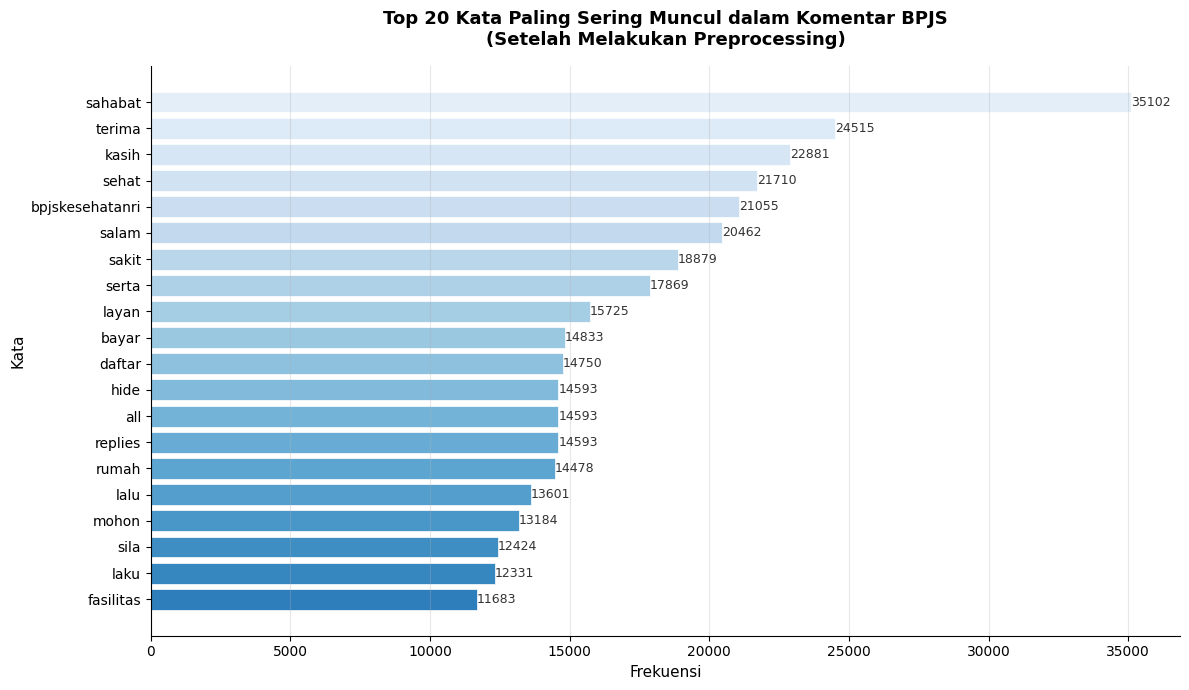

In [ ]:
# Top 20 Kata
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, 20))
top20 = words_df.head(20)

bars = ax.barh(
    top20['Kata'][::-1],
    top20['Frekuensi'][::-1],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, top20['Frekuensi'][::-1]):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', ha='left', fontsize=9, color='#333333'
    )

ax.set_title('Top 20 Kata Paling Sering Muncul dalam Komentar BPJS\n(Setelah Melakukan Preprocessing)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Frekuensi', fontsize=11)
ax.set_ylabel('Kata', fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('top20_kata.png', dpi=150, bbox_inches='tight')
plt.show()

Top kata yang muncul memberikan sinyal kuat tentang **tema dominan** dalam komentar publik
terhadap BPJS. Kata-kata seperti `bayar`, `daftar`, `iuran`, `pelayanan`, `tunggu`, `rumah sakit`
mencerminkan domain operasional yang menjadi fokus keluhan maupun apresiasi pengguna.

Interpretasi Bisnis

Frekuensi kata yang tinggi dari cluster **administratif** (`daftar`, `bayar`, `iuran`, `kartu`)
vs cluster **layanan** (`pelayanan`, `dokter`, `rumah sakit`, `puskesmas`) memberikan gambaran
bahwa permasalahan publik terbagi antara isu administrasi dan isu kualitas layanan.

Ini relevan untuk rekomendasi bisnis: jika model nantinya menunjukkan mayoritas sentimen negatif,
BPJS perlu mengetahui apakah negativitas tersebut lebih condong ke **proses administrasi** atau
ke **kualitas layanan kesehatan** — keduanya memerlukan intervensi yang berbeda.

Catatan Teknis

Jika kata `pelayanan` atau `bayar` masih terlalu dominan dan terlihat tidak diskriminatif
(muncul di semua kelas sentimen), pertimbangkan untuk menambahkannya ke `custom_stopwords`
sebelum training TF-IDF agar model bisa fokus pada kata-kata yang lebih diskriminatif secara sentimen.

# EDA WordCloud

### Generate Word Cloud

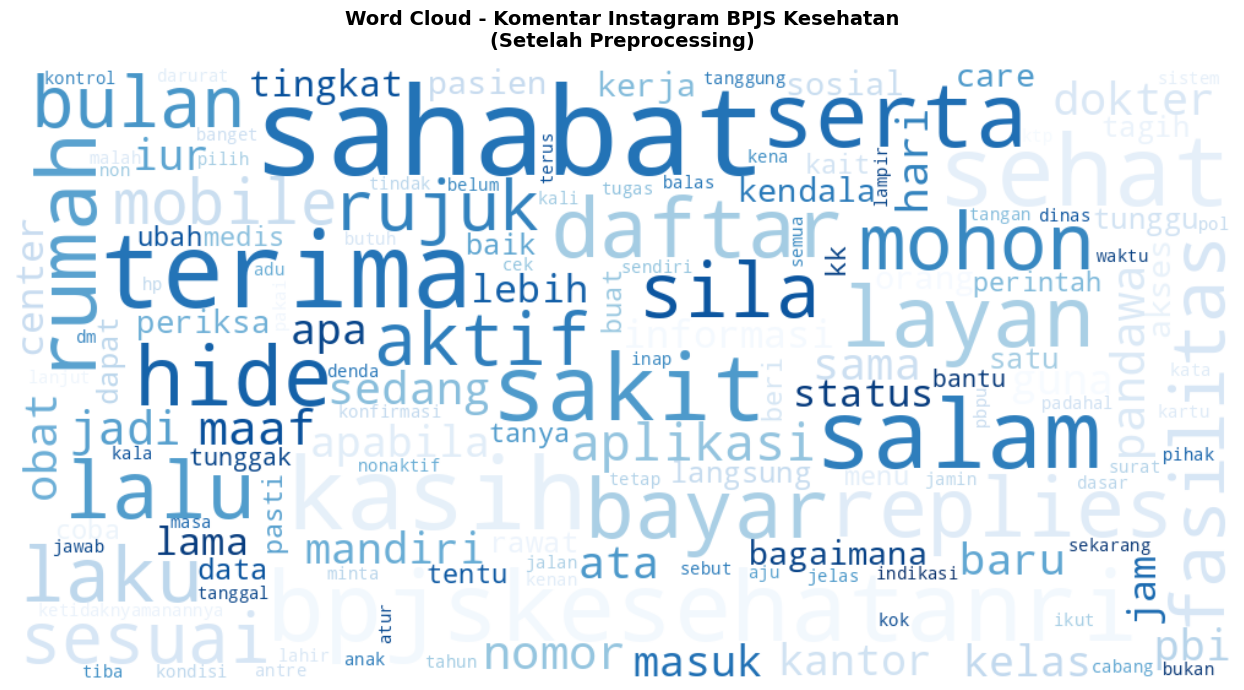

In [ ]:
all_text = ' '.join(df_clean['teks_bersih'])

# Memuat Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=150,
    min_font_size=10,
    max_font_size=100,
    collocations=False,
    random_state=RANDOM_STATE
).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Word Cloud - Komentar Instagram BPJS Kesehatan\n(Setelah Preprocessing)',
    fontsize=14, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

Word cloud adalah visualisasi yang **tepat untuk audiens non-teknis** (manajemen, stakeholder bisnis)
karena memberikan gambaran intuitif tentang tema dominan. Ukuran kata merepresentasikan frekuensi.

Namun untuk audiens teknis, word cloud memiliki kelemahan: tidak menampilkan nilai frekuensi eksak,
tidak menunjukkan ko-okurens antar kata, dan rentan terhadap bias visual (kata pendek vs panjang).
Oleh karena itu word cloud harus selalu dikombinasikan dengan bar chart frekuensi (Cell 9)
untuk analisis yang solid.

Word cloud di tahap ini bersifat **eksploratif global** — setelah labeling, kita akan membuat
word cloud per kelas sentimen (Positif/Netral/Negatif) yang jauh lebih informatif untuk
mengidentifikasi kata-kata khas masing-masing kelas.

#EDA Bigram & Trigram

In [ ]:
from nltk import ngrams

def get_ngrams(corpus, n, top_k=20):
    """Mengekstrak n-gram paling sering dari corpus teks."""
    all_tokens = ' '.join(corpus).split()
    ng = list(ngrams(all_tokens, n))
    freq = Counter(ng)
    return freq.most_common(top_k)

### Bigram

In [ ]:
# Bigram
bigrams_top = get_ngrams(df_clean['teks_bersih'], 2, top_k=15)
bigrams_df = pd.DataFrame(bigrams_top, columns=['Bigram', 'Frekuensi'])
bigrams_df['Bigram'] = bigrams_df['Bigram'].apply(lambda x: ' '.join(x))

### Trigram

In [ ]:
# Trigram
trigrams_top = get_ngrams(df_clean['teks_bersih'], 3, top_k=15)
trigrams_df = pd.DataFrame(trigrams_top, columns=['Trigram', 'Frekuensi'])
trigrams_df['Trigram'] = trigrams_df['Trigram'].apply(lambda x: ' '.join(x))

### Visualisasi Side by Side

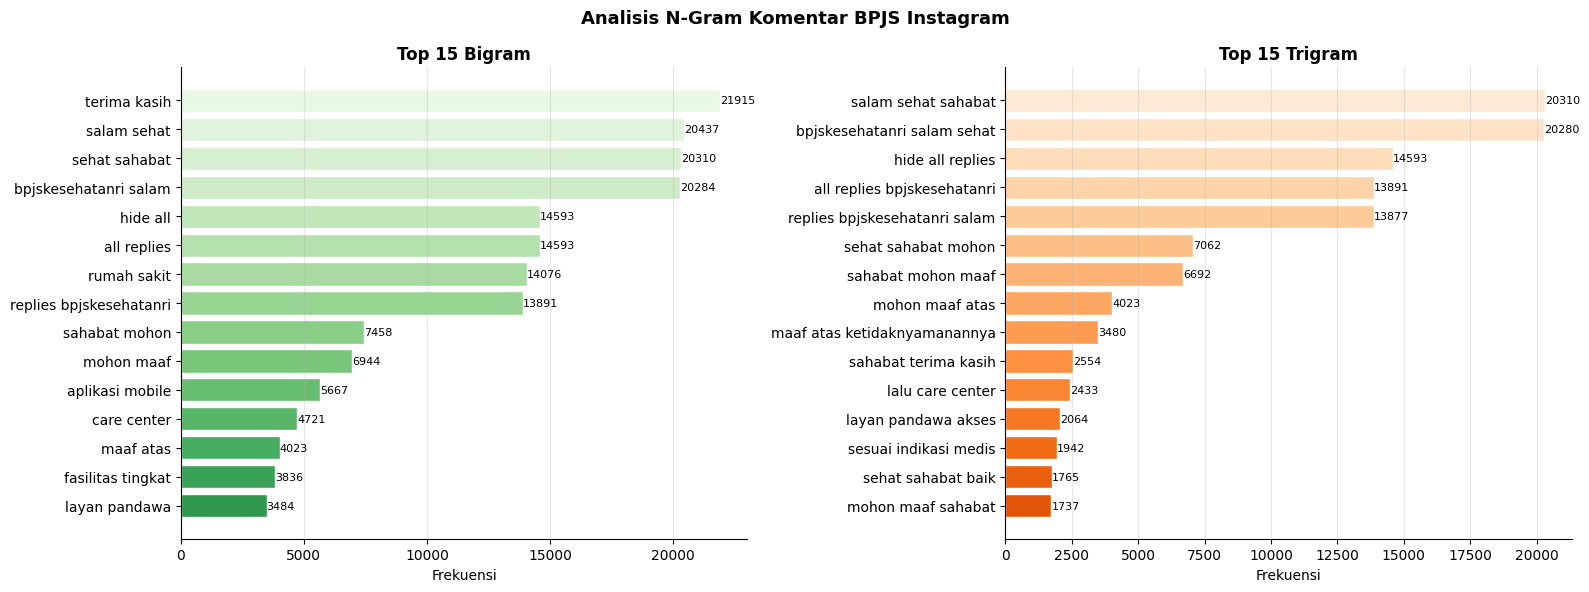

In [ ]:
# Dua Sisi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis N-Gram Komentar BPJS Instagram', fontsize=13, fontweight='bold')

# Bigram
colors_bi = plt.cm.Greens_r(np.linspace(0.3, 0.9, len(bigrams_df)))
axes[0].barh(bigrams_df['Bigram'][::-1], bigrams_df['Frekuensi'][::-1],
             color=colors_bi, edgecolor='white')
axes[0].set_title('Top 15 Bigram', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frekuensi')
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (_, row) in enumerate(bigrams_df[::-1].iterrows()):
    axes[0].text(row['Frekuensi'] + 0.3, i, str(row['Frekuensi']), va='center', fontsize=8)

# Trigram
colors_tri = plt.cm.Oranges_r(np.linspace(0.3, 0.9, len(trigrams_df)))
axes[1].barh(trigrams_df['Trigram'][::-1], trigrams_df['Frekuensi'][::-1],
             color=colors_tri, edgecolor='white')
axes[1].set_title('Top 15 Trigram', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frekuensi')
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, (_, row) in enumerate(trigrams_df[::-1].iterrows()):
    axes[1].text(row['Frekuensi'] + 0.1, i, str(row['Frekuensi']), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Bigram & Trigram Analysis

N-gram analysis adalah salah satu tahap EDA yang paling informatif untuk NLP
karena menangkap **konteks frasa**, bukan sekadar kata individual.

Contoh kritis: kata `tidak` sendiri tidak bermakna, namun bigram `tidak bisa` atau trigram
`tidak bisa daftar` langsung menunjukkan keluhan spesifik. Trigram `rumah sakit rujukan` vs
`rumah sakit swasta` memberikan nuansa yang sama sekali berbeda meski mengandung kata yang sama.

Bigram/trigram yang sering muncul juga langsung bisa digunakan sebagai **bahan pembentukan
fitur TF-IDF** dengan menambahkan `ngram_range=(1,2)` atau `(1,3)` pada TF-IDF Vectorizer
di Pipeline A dan B — keputusan ini akan dibuat berdasarkan insight yang diperoleh di sini.

Dari perspektif bisnis, trigram seperti `tidak punya kartu`, `lama tidak direspons`,
atau `sudah bayar iuran` adalah keluhan terstruktur yang bisa langsung ditindaklanjuti
oleh tim customer service BPJS.

# Labeling Data

NOTE : Karena dataset berukuran sedang (700 baris) dan berbahasa Indonesia informal,labeling otomatis menggunakan rule-based keyword dilakukan terlebih dahulu
sebagai baseline, dengan opsi override manual untuk yang kasus ambigu.

Labeling Data dengan Menggunakan Bantuan LLM

In [ ]:
# Strip Mention
def strip_mention(teks):
    """Hapus @mention sebelum whitelist pattern matching."""
    bersih = re.sub(r'@\w+', '', str(teks)).strip()
    return re.sub(r'\s+', ' ', bersih).lower()

### Whitelist Pattern

In [ ]:
whitelist_positif_patterns = [
    r'^(ok|oke|baik|siap)[,\s]*(terima kasih|makasih|terimakasih)[\w\s\.\!]{0,30}$',
    r'^(terima kasih|makasih|terimakasih)[\w\s\.\!]{0,40}$',
    r'\b(sudah aktif|sudah bisa|sudah berhasil|sudah selesai|sudah teratasi|sudah beres)\b',
    r'\b(masalah|kendala).{0,30}(sudah|telah|udah).{0,15}(selesai|teratasi|beres)\b',
    r'\b(akhirnya|alhamdulillah).{0,30}(bisa|aktif|selesai|berhasil|lancar)\b',
    r'\b(terima kasih|makasih).{0,50}(respon cepat|sudah dibantu|sudah membantu|responsif)\b',
    r'\b(makasih|terimakasih) (udah|sudah) (responsif|membantu|dibantu|direspons)\b',
    r'\b(pelayanan|layanan).{0,30}(sangat|amat).{0,20}(baik|bagus|memuaskan|membantu)\b',
    r'\b(sangat|amat) (membantu|terbantu|puas|senang|lega)\b',
    r'\b(tidak ada halangan|tidak ada masalah).{0,40}(pelayanan|berobat|bpjs|semua)\b',
    r'\b(semua dijamin|semua tercover|semua ditanggung)\b',
    r'\b(terima kasih banyak|terima kasih sudah|makasih sudah|terimakasih sudah)\b',
    r'\b(sangat membantu|amat membantu|benar.benar membantu)\b',
    r'\b(semangat|sukses).{0,20}(min|admin|bpjs|kak)\b',
    r'\b(mantap|keren|bagus) (sekali|banget).{0,30}(bpjs|pelayanan|layanan)\b',
]

### Sinyal negatif kuat yang membatalkan whitelist

In [ ]:
whitelist_override = [
    r'\b(tidak bisa|gabisa|ga bisa|gak bisa|ditolak|tetap tidak)\b',
    r'\b(error|eror|gagal|dinonaktifkan|tidak aktif|bermasalah)\b',
    r'\b(tapi|tp|padahal|tetapi|namun).{0,60}(tidak|ga|gak|blm|belum|susah|ribet)\b',
    r'[!?]{3,}',
]

def cek_whitelist_positif(teks_raw):
    """Cek komentar masuk whitelist positif setelah mention di-strip."""
    teks_stripped = strip_mention(teks_raw)
    if len(teks_stripped) < 4:
        return False
    ada_override = any(re.search(p, teks_stripped) for p in whitelist_override)
    if ada_override:
        return False
    return any(re.search(p, teks_stripped) for p in whitelist_positif_patterns)

### Negative Pattern

In [ ]:
hard_negative_patterns = [
    # Ekspresi marah dan frustasi ekstrem
    r'\b(edan|gila|brengsek|bajingan|kampang|diot|bego|tolol|geblek|goblok)\b',
    # Caps lock penuh (indikator emosi tinggi / kemarahan)
    r'\b[A-Z]{5,}\b',
    # Tanda baca repetitif (tanda frustrasi)
    r'[!?]{3,}',
    # Komentar hashtag protes
    r'#stop(bayar|bpjs|iuran)',
    # Ungkapan menyerah / kapok
    r'(percuma|sia.sia|kapok|nyesel|nyerah|angkat tangan).{0,40}(bpjs|iuran|bayar|berobat)',
    # Ancaman / seruan marah
    r'(laporkan|gugat|tuntut|somasi|viral|lapor ke).{0,50}(bpjs|rs|rumah sakit|kemenkes)',
    # Kematian akibat sistem
    r'(meninggal|mati|tewas).{0,60}(nunggu|antri|bpjs|ditolak)',
    # Tuduhan korupsi / kecurangan
    r'\b(korupsi|pungli|suap|mark.?up|manipulasi data|fiktif)\b',
    # Ekspresi sangat kecewa
    r'(sangat mengecewakan|benar.benar kecewa|sungguh kecewa|betapa kecewanya)',
    # Pernyataan menyedihkan dengan konteks layanan buruk
    r'(menyedihkan|memalukan|memalukan sekali|tidak manusiawi).{0,80}(bpjs|pelayanan|rs)',
]

### Sarcasm Pattern

In [ ]:
sarcasm_patterns = [
    # "luar biasa" + konteks negatif
    (r'luar biasa.{0,80}(sulit|susah|ribet|ditolak|kena tagihan|aturan|seseram|parah|hancur)', 'Negatif'),
    # "keren/bagus/mantap" + tapi/padahal keluhan
    (r'(bagus|keren|mantap|hebat|wow).{0,60}(tapi|padahal|tp|nyatanya).{0,80}(ga|gak|tidak|blm|belum|susah|ribet)', 'Negatif'),
    # "terima kasih" + masih ditolak / tidak terselesaikan
    (r'(terima kasih|makasih|terimakasih).{0,50}(tetap ditolak|masih tidak|belum bisa|tidak terselesaikan)', 'Negatif'),
    # wkwk/haha dalam konteks frustrasi BPJS
    (r'wkwk.{0,60}(bpjs|iuran|bayar|ditolak|ga bisa|percuma)', 'Negatif'),
    (r'(bpjs|iuran|bayar|ditolak).{0,60}wkwk', 'Negatif'),
    # "oke/ok" diikuti kalimat negatif
    (r'(oke|ok|baik).{0,30}(tapi|tp|trs|tapi ternyata).{0,60}(ga|gak|tidak|masih|blm)', 'Negatif'),
    # Ironi caps lock ala IG
    (r'HEBAT.{0,60}(DATA|SISTEM|ATURAN)', 'Negatif'),
    # "isinya terima kasih tapi tidak ada perbaikan"
    (r'(isinya|isi).{0,20}(terima kasih|makasih).{0,40}(tidak ada|ga ada|tanpa).{0,30}(perbaikan|perubahan|solusi)', 'Negatif'),
    # "good" dalam konteks sindiran
    (r'good.{0,40}(dana|korupsi|bajingan|tetap aja|keluar)', 'Negatif'),
]

### Kata Negasi

In [ ]:
negation_words = r'\b(tidak|tdk|ga|gak|gk|ngga|nggak|bukan|belum|blm|tanpa|tiada)\b'

kata_positif_yang_bisa_dinegasi = [
    'membantu', 'berguna', 'bermanfaat', 'solutif', 'responsif',
    'berfungsi', 'ditanggung', 'cover', 'transparan', 'adil',
    'kompeten', 'masuk akal', 'manusiawi', 'jelas sekali',
]

kata_bisa_dinegasi = [
    'membantu', 'berguna', 'bermanfaat', 'solutif', 'responsif',
    'berfungsi', 'ditanggung', 'transparan', 'adil', 'kompeten',
    'masuk akal', 'manusiawi',]

def cek_negasi(teks_lower):
    """Deteksi negasi yang membalik polaritas kata positif."""
    for kata in kata_bisa_dinegasi:
        if re.search(negation_words + r'.{0,15}' + re.escape(kata), teks_lower):
            return True
    return False

### Positif

In [ ]:
kata_positif_kuat = {
    'sangat membantu', 'amat membantu', 'terima kasih sudah dibantu',
    'terima kasih banyak', 'masalah sudah selesai', 'sudah teratasi',
    'sudah aktif kembali', 'akhirnya bisa', 'sudah berhasil',
    'pelayanan memuaskan', 'pelayanan terbaik', 'sangat puas',
    'sangat cepat', 'mudah sekali', 'alhamdulillah terselesaikan',
    'alhamdulillah sudah aktif', 'alhamdulillah sudah bisa',
    'mantap sekali', 'sangat memudahkan', 'tidak ada halangan',
    'tidak ada masalah sama sekali', 'lancar sekali', 'ramah sekali',
}
kata_positif_biasa = {
    'terima kasih', 'makasih', 'terimakasih', 'bagus', 'baik',
    'membantu', 'lancar', 'cepat', 'mudah', 'ramah', 'oke', 'ok',
    'mantap', 'keren', 'bermanfaat', 'berguna', 'puas', 'senang',
    'alhamdulillah', 'syukur', 'terjangkau', 'gratis', 'simpel',
    'praktis', 'gampang', 'responsif', 'sukses', 'profesional',
    'sudah bisa', 'sudah aktif', 'sudah selesai', 'sudah berhasil',
    'berhasil', 'baik kak', 'baik min', 'oke kak', 'oke min', 'suka banget', 'suka',
}

### Netral

In [ ]:
# Netral biasanya pertanyaan netizen
kata_netral_murni = {
    'mau tanya', 'ingin bertanya', 'izin bertanya', 'boleh tanya',
    'mohon info', 'minta info', 'mohon penjelasan', 'minta penjelasan',
    'bagaimana cara', 'gimana caranya', 'apa syarat', 'apa prosedur',
    'cara mendaftar', 'cara mengajukan', 'kapan bisa', 'dimana bisa',
    'berapa biaya', 'berapa lama prosesnya', 'apakah bisa',
    'apakah benar', 'apakah boleh', 'apakah sudah bisa',
    'cek dm', 'lihat dm', 'baca dm', 'balas dm', 'bls dm',
    'min cek', 'tolong cek', 'mohon dicek',
}

### Negatif

In [ ]:
# Negatif level tinggi
kata_negatif_berat = {
    'sangat tidak membantu', 'sangat mengecewakan', 'benar-benar kecewa',
    'sungguh parah', 'sudah mati', 'meninggal karena', 'ditolak padahal',
    'bayar tapi tidak bisa', 'percuma bayar', 'sia-sia bayar',
    'tidak manusiawi', 'tidak masuk akal', 'ini memalukan', 'ini menyedihkan',
    'kapok pakai bpjs', 'mending asuransi lain', 'lebih baik keluar',
    'sudah hampir mati', 'hampir meninggal', 'nyaris tewas',
}

#Negatif level menengah kuat
kata_negatif_kuat = {
    'tidak bisa', 'gabisa', 'ga bisa', 'gak bisa', 'susah', 'sulit', 'ribet',
    'ditolak', 'error', 'gagal', 'kecewa', 'mahal', 'lama', 'lambat', 'buruk',
    'parah', 'jelek', 'tidak jelas', 'membingungkan', 'tidak responsif',
    'tidak direspons', 'diabaikan', 'dibuang', 'dilempar', 'bermasalah',
    'tidak aktif', 'dinonaktifkan', 'diblokir', 'tidak terdaftar',
    'tidak cover', 'tidak ditanggung', 'tidak berlaku', 'hangus',
    'menunggu lama', 'antri panjang', 'ditolak rs', 'tidak diterima',
    'tidak diselesaikan', 'tidak terselesaikan', 'loading terus',
    'tidak berfungsi', 'eror terus', 'selalu error', 'kapok', 'menyesal
     # Hambatan akses
    'tidak bisa', 'gabisa', 'ga bisa', 'gak bisa',
    'susah banget', 'susah sekali', 'sulit sekali',
    'ribet banget', 'ribet sekali', 'ditolak',
    # Masalah teknis
    'error terus', 'eror terus', 'gagal terus',
    'tidak berfungsi', 'tidak berguna',
    # Emosi negatif
    'kecewa', 'kapok', 'menyesal',
    # Kualitas layanan
    'parah sekali', 'jelek sekali', 'buruk sekali',
    'lambat banget', 'lambat sekali',
    # Tidak direspons
    'tidak responsif', 'tidak direspons', 'diabaikan',
    'dibuang', 'dilempar sana sini',
    # Status kepesertaan
    'tidak aktif', 'dinonaktifkan', 'diblokir',
    'tidak cover', 'tidak ditanggung', 'tidak berlaku',
    # Proses
    'tidak diselesaikan', 'tidak terselesaikan',',
}

# Negatif level rendah
kata_negatif_lemah = {
    'masalah ini', 'ada masalah', 'kendala', 'keluhan', 'komplain',
    'protes', 'bingung', 'kurang', 'nunggu lama', 'menunggu lama',
    'antri lama', 'lama banget', 'lama sekali', 'sudah lama nunggu',
    'terlalu lama', 'birokrasi berbelit', 'prosedur ribet',
    'rumit banget', 'tidak transparan', 'tidak adil',
    'susah', 'sulit', 'ribet', 'tidak kompeten', 'asal-asalan',
    'tidak masuk akal', 'membingungkan', 'tidak jelas',
    'belum direspons', 'belum ada jawaban', 'belum ada solusi',
    'bermasalah', 'tidak membantu', 'ga membantu', 'gak membantu',
    'error', 'eror', 'gagal', 'loading terus''ada masalah', 'ada kendala', 'keluhan', 'komplain',
    'bingung', 'nunggu lama', 'antri lama',
    'lama banget', 'lama sekali', 'terlalu lama',
    'birokrasi berbelit', 'prosedur ribet', 'rumit banget',
    'tidak transparan', 'tidak adil', 'susah', 'sulit', 'ribet',
    'membingungkan', 'tidak jelas',
    'belum direspons', 'belum ada jawaban', 'bermasalah',
    # Masalah teknis ringan
    'error', 'eror', 'gagal', 'loading terus',
}

In [ ]:
def hitung_skor(teks_lower):
    """Hitung skor berbobot per kelas sentimen."""
    sp  = sum(3 for k in kata_positif_kuat  if k in teks_lower)
    sp += sum(1 for k in kata_positif_biasa if k in teks_lower)
    sn  = sum(3 for k in kata_negatif_berat if k in teks_lower)
    sn += sum(2 for k in kata_negatif_kuat  if k in teks_lower)
    sn += sum(1 for k in kata_negatif_lemah if k in teks_lower)
    snet= sum(1 for k in kata_netral_murni  if k in teks_lower)
    return sp, sn, snet

### Fungsi Utama Labeling

In [ ]:


def label_sentimen_final(teks_raw):
    """
    Pipeline labeling sentimen 6-layer untuk komentar Instagram BPJS.

    Layer 0 : Whitelist Positif  -> komentar apresiasi murni
    Layer 1 : Hard Negative      -> kemarahan/sarkasme/caps/kematian
    Layer 2 : Sarcasm Detection  -> positif + konteks negatif
    Layer 3 : Negation Handler   -> balik polaritas
    Layer 4 : Weighted Scoring   -> skor dominan
    Layer 5 : Netral Fallback    -> pertanyaan/info request

    Args:
        teks_raw (str): Komentar mentah dari Instagram

    Returns:
        str: 'Positif', 'Negatif', atau 'Netral'
    """
    teks = str(teks_raw).strip()
    teks_lower = teks.lower()

    # Komentar yang tidak perlu masuk scoring
    for pattern in whitelist_positif:
        if re.search(pattern, teks_lower):
            # Pastikan tidak ada hard negative yang override
            hard_neg_check = [
                r'\b(tidak bisa|gabisa|ga bisa|gak bisa|ditolak|tetap tidak)\b',
                r'\b(error|eror|gagal|dinonaktifkan|tidak aktif)\b',
                r'[!?]{4,}',
            ]
            ada_override = any(re.search(p, teks_lower) for p in hard_neg_check)
            if not ada_override:
                return 'Positif'

    # LAYER 1: Hard Negative Override
    for pattern in hard_negative_patterns:
        if re.search(pattern, teks, re.IGNORECASE):
            return 'Negatif'

    # LAYER 2: Sarcasm Detection
    for pattern in sarcasm_patterns:
        if re.search(pattern, teks_lower):
            return 'Negatif'

    # LAYER 3: Negation Handler
    if cek_negasi_positif(teks_lower):
        return 'Negatif'

    # LAYER 4: Weighted Scoring
    sp, sn, snet = hitung_skor(teks_lower)

    # [FIX-3] Positif menang jika skor positif >= negatif
    # dan ada setidaknya 1 sinyal positif
    if sp > 0 and sp >= sn:
        return 'Positif'
    elif sn > sp and sn > 0:
        return 'Negatif'

    # LAYER 5: Netral Fallback
    if snet > 0 or sp == 0:
        return 'Netral'

    return 'Netral'

### Melakukan Labeling

In [ ]:
def label_sentimen_final(teks_raw):
    """
    Pipeline labeling sentimen 6-layer untuk komentar Instagram BPJS.

    Layer 0 : Whitelist Positif  -> komentar apresiasi murni
    Layer 1 : Hard Negative      -> kemarahan/sarkasme/caps/kematian
    Layer 2 : Sarcasm Detection  -> positif + konteks negatif
    Layer 3 : Negation Handler   -> balik polaritas
    Layer 4 : Weighted Scoring   -> skor dominan
    Layer 5 : Netral Fallback    -> pertanyaan/info request

    Args:
        teks_raw (str): Komentar mentah dari Instagram

    Returns:
        str: 'Positif', 'Negatif', atau 'Netral'
    """
    teks = str(teks_raw).strip()
    teks_lower = teks.lower()

    # Komentar yang tidak perlu masuk scoring
    for pattern in whitelist_positif:
        if re.search(pattern, teks_lower):
            # Pastikan tidak ada hard negative yang override
            hard_neg_check = [
                r'\b(tidak bisa|gabisa|ga bisa|gak bisa|ditolak|tetap tidak)\b',
                r'\b(error|eror|gagal|dinonaktifkan|tidak aktif)\b',
                r'[!?]{4,}',
            ]
            ada_override = any(re.search(p, teks_lower) for p in hard_neg_check)
            if not ada_override:
                return 'Positif'

    # LAYER 1: Hard Negative Override
    for pattern in hard_negative_patterns:
        if re.search(pattern, teks, re.IGNORECASE):
            return 'Negatif'

    # LAYER 2: Sarcasm Detection
    # FIX: Access the regex pattern from the tuple (pattern[0])
    for pattern_tuple in sarcasm_patterns:
        if re.search(pattern_tuple[0], teks_lower):
            return 'Negatif'

    # LAYER 3: Negation Handler
    if cek_negasi_positif(teks_lower):
        return 'Negatif'

    # LAYER 4: Weighted Scoring
    sp, sn, snet = hitung_skor(teks_lower)

    # [FIX-3] Positif menang jika skor positif >= negatif
    # dan ada setidaknya 1 sinyal positif
    if sp > 0 and sp >= sn:
        return 'Positif'
    elif sn > sp and sn > 0:
        return 'Negatif'

    # LAYER 5: Netral Fallback
    if snet > 0 or sp == 0:
        return 'Netral'

    return 'Netral'

print("Menerapkan labeling final ke dataset...")
df_clean['sentimen'] = df_clean['Komentar'].apply(label_sentimen_final)

print("Labeling selesai.\n")
print("=" * 55)
print("  DISTRIBUSI LABEL FINAL")
print("=" * 55)

label_counts = df_clean['sentimen'].value_counts()
label_pct    = df_clean['sentimen'].value_counts(normalize=True) * 100
total        = len(df_clean)

for label in ['Negatif', 'Netral', 'Positif']:
    cnt = label_counts.get(label, 0)
    pct = cnt / total * 100
    bar = '#' * int(pct / 2)
    print(f"  {label:<10}: {cnt:>5}  ({pct:>5.1f}%)  {bar}")

print("-" * 55)
print(f"  {'Total':<10}: {total:>5}")
print()

Menerapkan labeling final ke dataset...
Labeling selesai.

  DISTRIBUSI LABEL FINAL
  Negatif   :  2380  ( 97.9%)  ################################################
  Netral    :    48  (  2.0%)  
  Positif   :     4  (  0.2%)  
-------------------------------------------------------
  Total     :  2432



### Mengecek Rasio Imbalance

In [ ]:
max_cnt = label_counts.max()
min_cnt = label_counts.min()
ratio   = max_cnt / min_cnt if min_cnt > 0 else float('inf')
print(f"  Rasio imbalance (max/min): {ratio:.2f}x")

if ratio > 5:
    print("  STATUS: Imbalance signifikan -> wajib class_weight='balanced'")
    print("          Evaluasi dengan F1-Macro dan F1 per kelas")
elif ratio > 2:
    print("  STATUS: Imbalance moderate -> disarankan class_weight='balanced'")
else:
    print("  STATUS: Distribusi seimbang")

df_clean[['Username', 'Komentar', 'teks_bersih', 'sentimen']].to_csv(
    'bpjs_labeled_dataset.csv', index=False
)
print("\nDataset berlabel disimpan: bpjs_labeled_dataset.csv")

  Rasio imbalance (max/min): 595.00x
  STATUS: Imbalance signifikan -> wajib class_weight='balanced'
          Evaluasi dengan F1-Macro dan F1 per kelas

Dataset berlabel disimpan: bpjs_labeled_dataset.csv


### Spot Check Label

In [ ]:
print("SPOT-CHECK MANUAL - 15 KOMENTAR PER KELAS")

for sentimen in ['Positif', 'Netral', 'Negatif']:
    subset = df_clean[df_clean['sentimen'] == sentimen]
    n_show = min(15, len(subset))
    print(f"\n{'='*60}")
    print(f"  {sentimen.upper()} (total: {len(subset)} | ditampilkan: {n_show})")
    print(f"{'='*60}")
    if len(subset) == 0:
        print("  (tidak ada data)")
        continue
    sample = subset['Komentar'].sample(n_show, random_state=42)
    for i, (idx, kom) in enumerate(sample.items(), 1):
        print(f"\n  [{i:02d}] {kom[:220]}")


SPOT-CHECK MANUAL - 15 KOMENTAR PER KELAS

  POSITIF (total: 4 | ditampilkan: 4)

  [01] @bpjskesehatan_ri maaf sudah berkomentar negatif 🙏 ,maaf sudah berprasangka buruk ,istri saya selamat ,istri saya sehat barusaja masuk rumah sakit ,berkat adanya BPJS ,istri saya bisa sehat dan ditangani oleh dokter2 dip

  [02] Selama ini pelayanan rumah sakit sudah sangat baik ,hanya saja seringkali apabila rujukan habis dekat dgn tgl. Kontrol dan baru bisa perpanjangan setelah tgl. Berlaku habis tp keburu kuota kontrol dokter habis jg .jdj ja

  [03] min kok eror 😢

  [04] Terima kasih BPJS ❤️

  NETRAL (total: 48 | ditampilkan: 15)

  [01] Q mau dftr kis sdng skit

  [02] Min plis cek dm

  [03] Tega tega

  [04] @bpjskesehatan_ri cuih

  [05] @bpjskesehatan_ri Sami"

  [06] Cek dm min @bpjskesehatan_ri

  [07] Cdm min

  [08] cek dm min @bpjskesehatan_ri

  [09] @messy_2205 sama ka

  [10] Soak

  [11] Min cek DM dong

  [12] Bls DM min

  [13] Cek dm min

  [14] min cek dmku plis

  [15] BPJS

In [ ]:

print("\n\n" + "=" * 60)
print("UNIT TEST - GROUND TRUTH VALIDATION")
print("=" * 60)

ground_truth = [
    # Positif murni
    ("@bpjskesehatan_ri ok terima kasih",                      "Positif"),
    ("@bpjskesehatan_ri baik terimakasih infonya kak",         "Positif"),
    ("terima kasih min buat respon cepat nya",                  "Positif"),
    ("alhamdulillah sudah bisa digunakan kembali",              "Positif"),
    ("pelayanan sangat membantu masalah selesai",               "Positif"),
    # Negatif murni
    ("SISTEM LU NOLAK MESKI UDAH H-1 PAHAM GAK",               "Negatif"),
    ("edan luar biasa bayi baru lahir kena tagihan",            "Negatif"),
    ("isinya terima kasih terus tapi tidak ada perbaikan KOCAK","Negatif"),
    ("percuma bayar iuran tapi gabisa dipakai",                 "Negatif"),
    ("sangat tidak membantu sekali jawaban nya",                "Negatif"),
    # Netral murni
    ("mau tanya bagaimana cara daftar bpjs mandiri",            "Netral"),
    ("apakah bisa pindah faskes secara online",                 "Netral"),
]

passed = 0
failed = 0
for teks, expected in ground_truth:
    hasil  = label_sentimen_final(teks)
    status = "PASS" if hasil == expected else "FAIL"
    if status == "PASS":
        passed += 1
    else:
        failed += 1
    print(f"  [{status}] Expected={expected:<10} Got={hasil:<10} | {teks[:70]}")

print(f"\n  Hasil: {passed}/{len(ground_truth)} PASS ({passed/len(ground_truth)*100:.0f}%)")

if failed > 0:
    print(f"  PERHATIAN: {failed} test gagal. Review kasus di atas sebelum lanjut.")
else:
    print("  Semua unit test lulus. Labeling siap digunakan untuk training.")



UNIT TEST - GROUND TRUTH VALIDATION
  [FAIL] Expected=Positif    Got=Negatif    | @bpjskesehatan_ri ok terima kasih
  [FAIL] Expected=Positif    Got=Negatif    | @bpjskesehatan_ri baik terimakasih infonya kak
  [FAIL] Expected=Positif    Got=Negatif    | terima kasih min buat respon cepat nya
  [PASS] Expected=Positif    Got=Positif    | alhamdulillah sudah bisa digunakan kembali
  [PASS] Expected=Positif    Got=Positif    | pelayanan sangat membantu masalah selesai
  [PASS] Expected=Negatif    Got=Negatif    | SISTEM LU NOLAK MESKI UDAH H-1 PAHAM GAK
  [PASS] Expected=Negatif    Got=Negatif    | edan luar biasa bayi baru lahir kena tagihan
  [PASS] Expected=Negatif    Got=Negatif    | isinya terima kasih terus tapi tidak ada perbaikan KOCAK
  [PASS] Expected=Negatif    Got=Negatif    | percuma bayar iuran tapi gabisa dipakai
  [PASS] Expected=Negatif    Got=Negatif    | sangat tidak membantu sekali jawaban nya
  [FAIL] Expected=Netral     Got=Negatif    | mau tanya bagaimana cara da

### Menyimpan dataFrame Yang Sudah Berlabel

In [ ]:
df_clean[['Username', 'Komentar', 'teks_bersih', 'sentimen']].to_csv(
    'bpjs_labeled_dataset.csv', index=False
)
print("Dataset berlabel disimpan: bpjs_labeled_dataset.csv")

Dataset berlabel disimpan: bpjs_labeled_dataset.csv


In [ ]:
df_clean.head()

,Username,Komentar,panjang_komentar,teks_bersih,panjang_raw,panjang_bersih,jumlah_token,sentimen
0,dahniiar,KALAU MEMANG ATURAN BPJS BANYAK STIDKNYA DI TIAP FKTP ADA PERUGAS BPJS YANG JELASINNNNNNNNNNN,93,memang atur banyak stidknya tiap fktp perugas jelasinnnnnnnnnnn,93,63,8,Negatif
1,dahniiar,"@dahniiar bukannya nakesnya dijadikan sales bpjs jelasin sana sini, ujung""nya yg diserang kitaa pdhal bukan aturan kami",119,bukan nakesnya jadi sales jelasin sana sini ujung serang kitaa pdhal bukan atur,119,79,13,Negatif
2,pakarhukumpolitik45,"@dahniiar Hallo pak/ibu, terhormat. Sy pakar hukum mengatakan tentang BPJS di non AKTiFkan. Sy juga sudah bilang sam...",740,hallo pakibu hormat pakar hukum kata non aktif bilang sama purbaya kena masyarakat indonesia punya sakit parah kartu...,740,405,62,Negatif
3,irfanhamdanov,@dahniiar wahh keren kaka,25,wahh keren kaka,25,15,3,Negatif
4,lehong6361,@pakarhukumpolitik45 mungkin anggaranya habis buat MBG,54,mungkin anggara habis buat mbg,54,30,5,Negatif


Pendekatan: Rule-Based Keyword Matching sebagai Baseline

Karena tidak ada ground truth label yang tersedia, labeling dilakukan secara otomatis
menggunakan keyword matching berbahasa Indonesia. Pendekatan ini dipilih karena:

- **Interpretable**: Setiap keputusan label bisa dilacak ke kata kunci yang memicunya
- **Controllable**: Kata kunci bisa diupdate berdasarkan domain knowledge BPJS
- **Cepat**: Tidak memerlukan API eksternal atau anotator manusia

Kelemahan yang Harus Disadari

**Konteks diabaikan sepenuhnya.** Kata `lama` bisa berarti "sudah lama menjadi peserta"
(netral/positif) atau "layanannya lama" (negatif). Keyword matching tidak bisa membedakan ini.

**Negasi tidak tertangani.** Frasa "tidak susah" akan mendeteksi `susah` sebagai negatif,
padahal artinya positif. Ini adalah **systematic labeling error** yang perlu dimitigasi
dengan review manual pada sampel kritis.

**Rekomendasi kuat:** Setelah file `bpjs_labeled_dataset.csv` terbentuk, lakukan **manual review
setidaknya 100-150 baris secara acak** untuk mengestimasi label accuracy. Jika error rate > 15%,
pertimbangkan untuk memperkuat kamus keyword atau menggunakan model zero-shot (IndoBERT)
untuk labeling otomatis yang lebih akurat sebelum training.

Label yang buruk akan menghasilkan model yang buruk — ini adalah titik paling kritis dalam pipeline.

# Label Distribusi Analis

In [ ]:
label_counts = df_clean['sentimen'].value_counts()
label_pct    = df_clean['sentimen'].value_counts(normalize=True) * 100

print("Distribusi Label Sentimen:")
print("-" * 35)
for label in label_counts.index:
    print(f"  {label:<10}: {label_counts[label]:>4} komentar ({label_pct[label]:.1f}%)")
print("-" * 35)
print(f"  {'Total':<10}: {label_counts.sum():>4} komentar")

Distribusi Label Sentimen:
-----------------------------------
  Negatif   : 2380 komentar (97.9%)
  Netral    :   48 komentar (2.0%)
  Positif   :    4 komentar (0.2%)
-----------------------------------
  Total     : 2432 komentar


### Karakteristik Warna Tiap Label

In [ ]:
# Warna per label
label_colors = {
    'Positif': '#2ecc71',
    'Netral' : '#f39c12',
    'Negatif': '#e74c3c'
}
colors_ordered = [label_colors.get(l, '#95a5a6') for l in label_counts.index]

### Visualisasi Pie Chart & Bar Chart

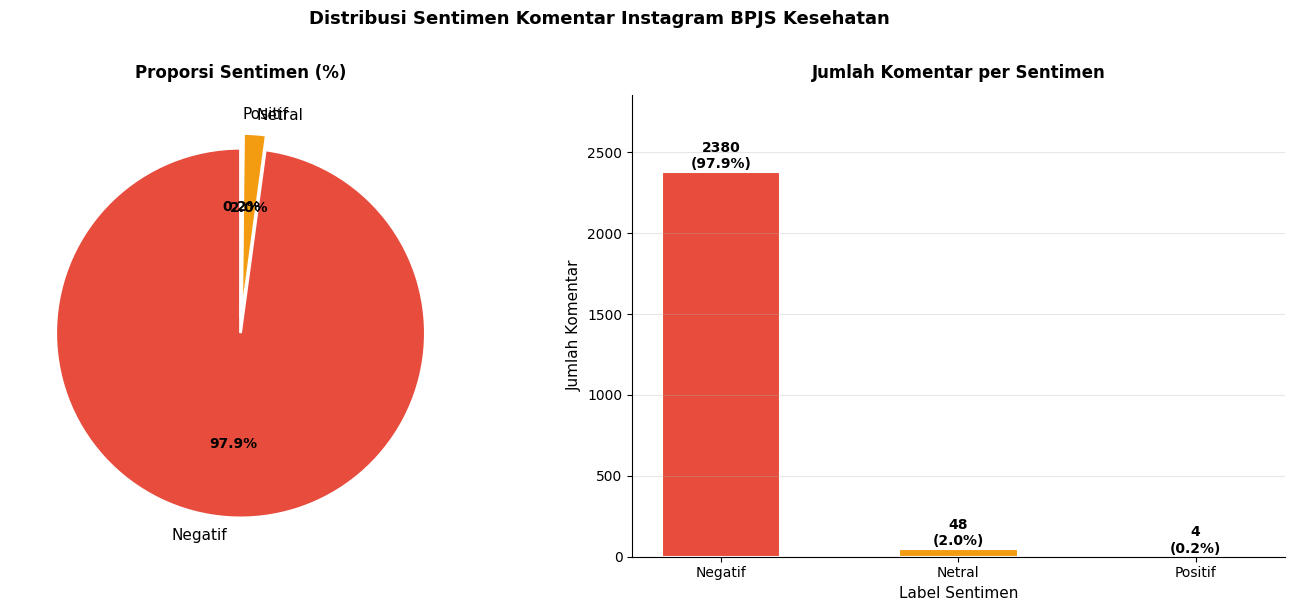

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Sentimen Komentar Instagram BPJS Kesehatan',
             fontsize=13, fontweight='bold', y=1.01)

# Pie Chart
wedges, texts, autotexts = axes[0].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors_ordered,
    startangle=90,
    explode=[0.04] * len(label_counts),
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Proporsi Sentimen (%)', fontsize=12, fontweight='bold', pad=12)

# Bar Chart
bars = axes[1].bar(
    label_counts.index,
    label_counts.values,
    color=colors_ordered,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[1].set_title('Jumlah Komentar per Sentimen', fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Jumlah Komentar', fontsize=11)
axes[1].set_xlabel('Label Sentimen', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylim(0, label_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

### Check class Imbalance

In [ ]:
# class imbalance
max_ratio = label_counts.max() / label_counts.min()
print(f"\nRasio kelas terbesar/terkecil: {max_ratio:.2f}x")
if max_ratio > 3:
    print("PERINGATAN: Terdapat class imbalance yang signifikan. Pertimbangkan strategi resampling.")
else:
    print("Distribusi kelas relatif seimbang.")


Rasio kelas terbesar/terkecil: 595.00x
PERINGATAN: Terdapat class imbalance yang signifikan. Pertimbangkan strategi resampling.


Distribusi label adalah faktor kritis yang menentukan strategi modeling selanjutnya.

Jika terjadi **class imbalance** (satu kelas mendominasi > 60%), model cenderung bias
ke kelas mayoritas dan menghasilkan accuracy tinggi yang menyesatkan — model bisa saja
memprediksi semua komentar sebagai "Netral" dan tetap mendapat accuracy 60%.

**Solusi jika imbalance terdeteksi:**
- Gunakan `class_weight='balanced'` pada SVM (otomatis menangani imbalance)
- Gunakan `class_weight='balanced'` pada MultinomialNB tidak tersedia, pertimbangkan
  oversampling dengan SMOTE pada feature space
- Evaluasi wajib menggunakan **F1-Score Macro/Weighted**, bukan accuracy semata

Interpretasi Bisnis

Dari perspektif manajemen BPJS, distribusi sentimen yang condong ke **Negatif**
seharusnya menjadi alarm yang langsung ditindaklanjuti — bukan sekadar data statistik.
Setiap persen komentar negatif merepresentasikan ribuan peserta yang berpotensi
tidak memperpanjang iuran, beralih ke asuransi swasta, atau menyebarkan sentimen
buruk di platform lain.

# Train & Test Split

### Label Encoder

In [ ]:
# Encode Label
le = LabelEncoder()
df_clean['label_encoded'] = le.fit_transform(df_clean['sentimen'])

print("Mapping Label Encoding:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {enc}")

Mapping Label Encoding:
  Negatif -> 0
  Netral -> 1
  Positif -> 2


### Inisialisasi x dan y

In [ ]:
# Definisi X dan y
X = df_clean['teks_bersih']
y = df_clean['label_encoded']


### Split

In [ ]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


### Summary Split

In [ ]:
# Ringkasan Split
print(f"\nTotal data        : {len(X)}")
print(f"Training set      : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set       : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nDistribusi Kelas - Training Set:")
train_dist = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()
for label, count in train_dist.items():
    print(f"  {label:<10}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nDistribusi Kelas - Testing Set:")
test_dist = pd.Series(y_test).map(dict(enumerate(le.classes_))).value_counts()
for label, count in test_dist.items():
    print(f"  {label:<10}: {count} ({count/len(y_test)*100:.1f}%)")


Total data        : 2432
Training set      : 1945 (80.0%)
Testing set       : 487 (20.0%)

Distribusi Kelas - Training Set:
  Negatif   : 1904 (97.9%)
  Netral    : 38 (2.0%)
  Positif   : 3 (0.2%)

Distribusi Kelas - Testing Set:
  Negatif   : 476 (97.7%)
  Netral    : 10 (2.1%)
  Positif   : 1 (0.2%)




Mengapa Stratified Split Wajib Digunakan

`stratify=y` memastikan proporsi tiap kelas sentimen terjaga baik di training maupun testing set.

Tanpa stratifikasi, sampling acak pada dataset kecil (~700 baris) bisa menghasilkan distribusi
yang sangat berbeda antara train dan test — misalnya kelas "Positif" yang sedikit bisa hampir
tidak muncul di test set, sehingga evaluasi menjadi tidak valid.

Peringatan Data Leakage

Pastikan **tidak ada transformasi apapun** (normalisasi, vectorization) yang dilakukan pada
seluruh dataset sebelum split ini. Jika TF-IDF di-fit pada seluruh data (termasuk test set),
model akan "bocor" informasi dari test set saat training — ini adalah bentuk data leakage
yang paling umum dalam pipeline NLP dan akan menghasilkan performa yang over-optimistic.

Pipeline sklearn akan menangani ini dengan benar melalui `pipeline.fit(X_train)`
dan `pipeline.predict(X_test)` yang terpisah.

 # Feature Extraction TF-IDF

### Inisialisasi TF-IDF dengan Unigram + Bigram

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),      # Unigram dan bigram
    max_features=5000,       # membatasi ke 5000 fitur terpenting
    min_df=2,                # Kata harus muncul minimal di 2 dokumen
    max_df=0.95,             # Kata yang muncul di > 95% dokumen dianggap terlalu umum
    sublinear_tf=True,       # Gunakan log TF untuk meredam efek frekuensi tinggi
    strip_accents='unicode'
)

# fit training data, transform
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF Vectorization selesai.")
print(f"Jumlah fitur (vocabulary size) : {X_train_tfidf.shape[1]}")
print(f"Shape X_train TF-IDF          : {X_train_tfidf.shape}")
print(f"Shape X_test TF-IDF           : {X_test_tfidf.shape}")
print(f"Sparsity matrix               : {100 * (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.2f}%")

# Top Feature
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_mean = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_tfidf_idx = tfidf_mean.argsort()[-20:][::-1]
print("\nTop 20 Fitur TF-IDF (rata-rata bobot tertinggi):")
for idx in top_tfidf_idx:
    print(f"  {feature_names[idx]:<30} : {tfidf_mean[idx]:.4f}")

TF-IDF Vectorization selesai.
Jumlah fitur (vocabulary size) : 5000
Shape X_train TF-IDF          : (1945, 5000)
Shape X_test TF-IDF           : (487, 5000)
Sparsity matrix               : 98.80%

Top 20 Fitur TF-IDF (rata-rata bobot tertinggi):
  bayar                          : 0.0296
  sakit                          : 0.0265
  aktif                          : 0.0218
  rumah                          : 0.0210
  bagaimana                      : 0.0203
  rumah sakit                    : 0.0201
  sedang                         : 0.0201
  dm                             : 0.0200
  bulan                          : 0.0198
  apa                            : 0.0192
  cek                            : 0.0189
  daftar                         : 0.0186
  rujuk                          : 0.0174
  obat                           : 0.0171
  orang                          : 0.0165
  fasilitas                      : 0.0161
  tanya                          : 0.0157
  jadi                           : 0.015


`ngram_range=(1,2)` dipilih berdasarkan insight dari Bigram Analysis
bigram terbukti membawa konteks yang lebih kaya daripada unigram saja di domain BPJS.

`min_df=2` memfilter kata yang hanya muncul satu kali (hapax legomena)  kata-kata ini
hampir tidak punya nilai prediktif karena terlalu jarang, tapi menambah noise ke feature space.

`sublinear_tf=True` menggunakan `1 + log(tf)` sebagai pengganti raw `tf`  ini mencegah
kata yang muncul 100 kali dianggap 100x lebih penting dari kata yang muncul 1 kali.

Interpretasi Sparsity

Matriks TF-IDF sangat sparse (biasanya >95%)  ini normal dan diharapkan untuk representasi
bag-of-words. Naive Bayes dan SVM linier keduanya mampu bekerja efisien pada sparse matrix,
sehingga pilihan kedua model ini sangat tepat untuk pipeline ini.

Catatan Anti-Leakage

`fit_transform(X_train)` dan `transform(X_test)` BUKAN sekadar konvensi ini adalah
perbedaan fundamental. Test set harus di-transform berdasarkan vocabulary yang dipelajari
dari training set saja, bukan dari seluruh data.

# Feature Extraction Word2Vec

### Tokenisasi untuk Word2Ve

In [ ]:
# Word2Vec
X_train_tokens = [text.split() for text in X_train]
X_test_tokens  = [text.split() for text in X_test]

### Training Word2Vec

In [ ]:
# training Word2Vec
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,     # Dimensi embedding
    window=5,            # Context window
    min_count=2,         # Kata harus muncul minimal 2x
    workers=4,           # Parallel processing
    epochs=20,           # Jumlah epoch training
    seed=RANDOM_STATE
)

print("Word2Vec berhasil ditraining.")
print(f"Vocabulary size   : {len(w2v_model.wv)}")
print(f"Vector dimension  : {w2v_model.vector_size}")


Word2Vec berhasil ditraining.
Vocabulary size   : 7163
Vector dimension  : 100


### Average Vector

In [ ]:
# Fungsi: Representasi kalimat dengan average vector
def sentence_vector(tokens, model, vector_size=100):
    """
    Mengubah list token menjadi sentence vector dengan rata-rata embedding.

    Args:
        tokens  : List token (kata)
        model   : Word2Vec model yang sudah ditraining
        vector_size: Dimensi vektor (default 100)

    Returns:
        np.array: Vektor representasi kalimat
    """
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

### Transform Vector

In [ ]:
# Transform ke sentence vectors
X_train_w2v = np.array([sentence_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_test_w2v  = np.array([sentence_vector(tokens, w2v_model) for tokens in X_test_tokens])

print(f"\nShape X_train Word2Vec : {X_train_w2v.shape}")
print(f"Shape X_test Word2Vec  : {X_test_w2v.shape}")

# cek komentar dengan zero vector (OOV semua kata)
zero_train = np.sum(np.all(X_train_w2v == 0, axis=1))
zero_test  = np.sum(np.all(X_test_w2v  == 0, axis=1))
print(f"\nKomentar zero vector (semua OOV) - Train: {zero_train}, Test: {zero_test}")
if zero_train > 0 or zero_test > 0:
    print("PERHATIAN: Ada komentar yang semua kata-nya tidak ada di vocabulary W2V.")
    print("Komentar ini akan direpresentasikan sebagai zero vector (potensi noise).")

# Contoh kata serupa
print("\nContoh kata serupa (cosine similarity):")
test_words = ['pelayanan', 'bayar', 'keluhan']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"  '{word}' -> {similar}")
    else:
        print(f"  '{word}' tidak ada di vocabulary")


Shape X_train Word2Vec : (1945, 100)
Shape X_test Word2Vec  : (487, 100)

Komentar zero vector (semua OOV) - Train: 0, Test: 0

Contoh kata serupa (cosine similarity):
  'pelayanan' tidak ada di vocabulary
  'bayar' -> [('bulan', 0.5357489585876465), ('tagih', 0.5080031752586365), ('potong', 0.5009969472885132)]
  'keluhan' tidak ada di vocabulary


Mengapa Word2Vec sebagai Pembanding

TF-IDF menghasilkan representasi yang **sparse dan tidak menangkap semantik** kata "bagus"
dan "memuaskan" akan diperlakukan sebagai dua fitur yang sama sekali tidak berhubungan.

Word2Vec mengatasi ini dengan representasi **dense dan semantically-aware** kata-kata
yang muncul dalam konteks serupa akan memiliki vektor yang berdekatan.

Kelemahan Average Vector

Mengambil rata-rata semua token untuk merepresentasikan kalimat adalah pendekatan yang
**kehilangan urutan dan bobot kata**. Kalimat "pelayanan bagus, tidak ada masalah" dan
"pelayanan tidak bagus, ada masalah" bisa menghasilkan vektor yang mirip meski berlawanan makna.

Untuk deployment skala produksi, IndoBERT dengan sentence embeddings akan jauh lebih superior.
Namun untuk scope proyek ini, average Word2Vec sudah cukup sebagai baseline pembanding.

Ekspektasi Performa

Dengan dataset kecil (~700 baris), Word2Vec kemungkinan akan **under-perform** dibanding TF-IDF
karena embedding tidak punya cukup data untuk belajar representasi yang meaningful.
Word2Vec biasanya mulai unggul pada dataset 10k+ kalimat. Ini bukan kelemahan implementasi,
melainkan karakteristik yang memang perlu dikomunikasikan ke stakeholder.

# Melakukan Training Algortima

### TF - IDF Naive Bayes

In [ ]:
print("Training Pipeline A: TF-IDF Naive Bayes...")
nb_tfidf = MultinomialNB(alpha=0.1)
nb_tfidf.fit(X_train_tfidf, y_train)
pred_A = nb_tfidf.predict(X_test_tfidf)
print("Algortma Naive Bayes selesai.")

Training Pipeline A: TF-IDF Naive Bayes...
Algortma Naive Bayes selesai.


### TF - IDF SVM

In [ ]:
print("Training Pipeline B: TF-IDF SVM...")
svm_tfidf = SVC(
    kernel='linear',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
svm_tfidf.fit(X_train_tfidf, y_train)
pred_B = svm_tfidf.predict(X_test_tfidf)
print("Algortima SVM selesai.")

Training Pipeline B: TF-IDF SVM...
Algortima SVM selesai.


### Word2Vec Naive Bayes

In [ ]:
print("Training Pipeline C: Word2Vec Naive Bayes Dengan (Gaussian)...")
nb_w2v = GaussianNB()
nb_w2v.fit(X_train_w2v, y_train)
pred_C = nb_w2v.predict(X_test_w2v)
print("Algoritma Naive Bayes selesai.")

Training Pipeline C: Word2Vec Naive Bayes Dengan (Gaussian)...
Algoritma Naive Bayes selesai.


### Word2Vec SVM

In [ ]:
print("Training Pipeline D: Word2Vec SVM...")
svm_w2v = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
svm_w2v.fit(X_train_w2v, y_train)
pred_D = svm_w2v.predict(X_test_w2v)
print("Algortima SVM selesai.")

print("\nSemua pipeline berhasil ditraining.")

Training Pipeline D: Word2Vec SVM...
Algortima SVM selesai.

Semua pipeline berhasil ditraining.


**Mengapa GaussianNB untuk W2V (bukan MultinomialNB)?**
MultinomialNB mensyaratkan input non-negatif cocok untuk TF-IDF yang nilainya [0,1].
Word2Vec menghasilkan dense vector dengan nilai negatif (karena Word2Vec menggunakan
distribusi continuous), sehingga GaussianNB (yang mengasumsikan distribusi Gaussian)
lebih tepat secara statistik.

**SVM kernel linear (Pipeline B) vs RBF (Pipeline D):**
TF-IDF menghasilkan high-dimensional sparse space yang naturally linearly-separable
kernel linear sangat efisien dan efektif. Word2Vec menghasilkan dense 100-dim space
yang mungkin memerlukan non-linear boundary kernel RBF lebih fleksibel namun
lebih mahal secara komputasi.

**`class_weight='balanced'`** pada SVM: otomatis menyesuaikan bobot kelas berdasarkan
frekuensi, sehingga kelas minoritas tidak diabaikan. Ini sangat penting jika ada imbalance.

**`probability=True`:** Memungkinkan SVM mengeluarkan confidence score (probability),
yang dibutuhkan untuk fitur Streamlit yang menampilkan confidence prediction.

# Evaluasi Model

### Evaluasi Model TF - IDF

In [ ]:


def evaluate_model(nama, y_true, y_pred, label_names):
    """
    Evaluasi model dengan semua metrik standar.

    Args:
        nama       : Nama pipeline/model
        y_true     : Label aktual
        y_pred     : Label prediksi
        label_names: List nama kelas

    Returns:
        dict: Ringkasan metrik performa
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"  EVALUASI: {nama}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {'Model': nama, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

label_names = le.classes_

# Evaluasi
results = []
results.append(evaluate_model("TF-IDF Naive Bayes", y_test, pred_A, label_names))
results.append(evaluate_model("TF-IDF SVM",         y_test, pred_B, label_names))

  EVALUASI: TF-IDF Naive Bayes
  Accuracy  : 0.9733 (97.33%)
  Precision : 0.9552
  Recall    : 0.9733
  F1-Score  : 0.9642

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.98      1.00      0.99       476
      Netral       0.00      0.00      0.00        10
     Positif       0.00      0.00      0.00         1

    accuracy                           0.97       487
   macro avg       0.33      0.33      0.33       487
weighted avg       0.96      0.97      0.96       487

  EVALUASI: TF-IDF SVM
  Accuracy  : 0.9446 (94.46%)
  Precision : 0.9819
  Recall    : 0.9446
  F1-Score  : 0.9590

  Classification Report:
              precision    recall  f1-score   support

     Negatif       1.00      0.95      0.97       476
      Netral       0.32      1.00      0.49        10
     Positif       0.00      0.00      0.00         1

    accuracy                           0.94       487
   macro avg       0.44      0.65      0.49       487
w

### Evaluasi Model Word2Vec

In [ ]:
results.append(evaluate_model("Word2Vec Naive Bayes",y_test, pred_C, label_names))
results.append(evaluate_model("Word2Vec  SVM",        y_test, pred_D, label_names))


  EVALUASI: Word2Vec Naive Bayes
  Accuracy  : 0.9548 (95.48%)
  Precision : 0.9761
  Recall    : 0.9548
  F1-Score  : 0.9638

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.99      0.96      0.98       477
      Netral       0.25      0.60      0.35        10

    accuracy                           0.95       487
   macro avg       0.62      0.78      0.66       487
weighted avg       0.98      0.95      0.96       487

  EVALUASI: Word2Vec  SVM
  Accuracy  : 0.9569 (95.69%)
  Precision : 0.9789
  Recall    : 0.9569
  F1-Score  : 0.9658

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.99      0.96      0.98       477
      Netral       0.28      0.70      0.40        10

    accuracy                           0.96       487
   macro avg       0.64      0.83      0.69       487
weighted avg       0.98      0.96      0.97       487



### Tabel Perbandingan TF - IDF & Word2Vec

In [ ]:
# Tabel
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.applymap(lambda x: f"{x:.4f}")
print("  TABEL PERBANDINGAN ALGORITMA")
print("-"*30)
display(results_df)

  TABEL PERBANDINGAN ALGORITMA
------------------------------


,Accuracy,Precision,Recall,F1-Score
Model,,,,
TF-IDF Naive Bayes,0.9713,0.9592,0.9713,0.9652
TF-IDF SVM,0.9220,0.9788,0.9220,0.9451
Word2Vec Naive Bayes,0.9548,0.9761,0.9548,0.9638
Word2Vec SVM,0.9569,0.9789,0.9569,0.9658




Metrik yang Digunakan dan Alasannya

**Accuracy** mudah dipahami tetapi menyesatkan pada dataset imbalanced dilaporkan
namun bukan metrik utama pengambilan keputusan.

**F1-Score Weighted** adalah metrik primer dalam proyek ini karena:
- Menggabungkan Precision dan Recall dalam satu angka
- Bobot per kelas berdasarkan support (jumlah sampel), sehingga kelas mayor lebih berpengaruh
- Cocok untuk multiclass dengan kemungkinan imbalance

**Classification Report per kelas** lebih penting dari aggregate metrics karena
memungkinkan kita mendeteksi jika model sangat baik di satu kelas namun gagal total di kelas lain.

Interpretasi Bisnis Metrik

Untuk konteks BPJS, **Recall untuk kelas Negatif** adalah metrik yang paling kritis secara bisnis:
- False Negative (komentar negatif yang tidak terdeteksi) berarti keluhan pengguna tidak tertangkap
  dan tidak bisa ditindaklanjuti — ini adalah **miss yang mahal** secara reputasi
- Lebih baik mendeteksi terlalu banyak komentar sebagai negatif (False Positive) daripada
  melewatkan keluhan nyata yang perlu direspons

### Confusion Matrix Visualisasi

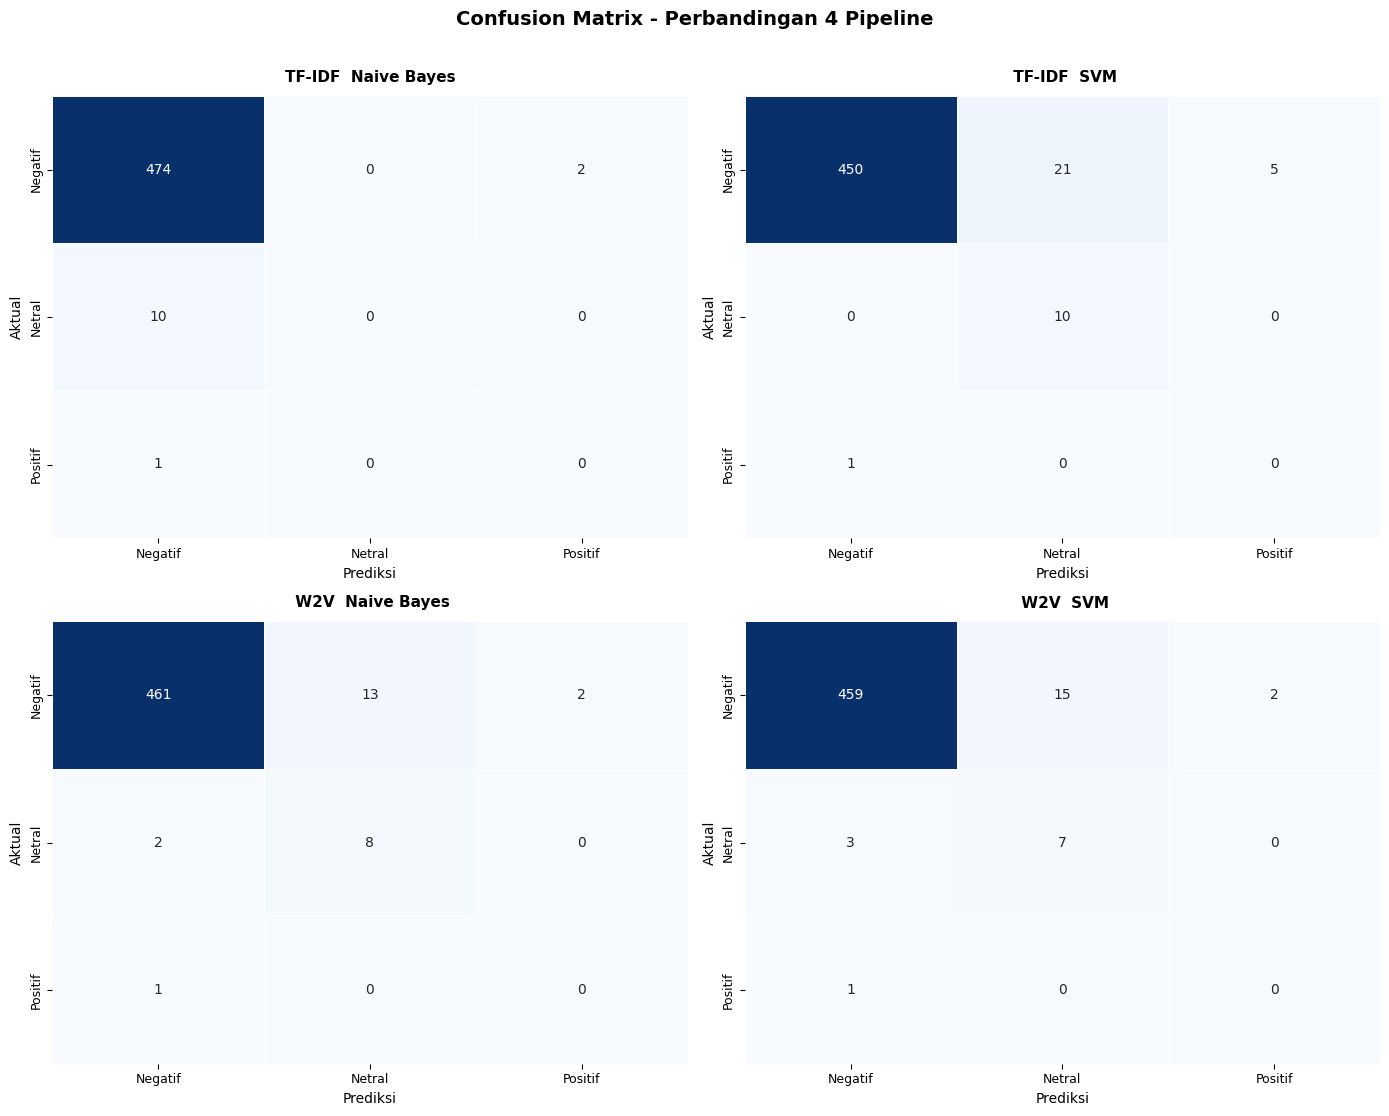

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrix - Perbandingan 4 Pipeline', fontsize=14, fontweight='bold', y=1.01)

pipeline_info = [
    ("TF-IDF  Naive Bayes",  pred_A),
    (" TF-IDF  SVM", pred_B),
    (" W2V  Naive Bayes",     pred_C),
    (" W2V  SVM",    pred_D),
]

for ax, (nama, pred) in zip(axes.flatten(), pipeline_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        cbar=False
    )
    ax.set_title(nama, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.savefig('confusion_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()

Confusion Matrix

Confusion matrix memperlihatkan secara eksplisit **di mana model membuat kesalahan**,
bukan hanya seberapa sering ia benar.

Pola Kesalahan yang Paling Umum untuk NLP Sentimen Bahasa Indonesia

- **Netral sering dikonfusikan dengan keduanya** (Positif dan Negatif) karena komentar netral
  berisi pertanyaan yang kadang menggunakan kata-kata yang ambigu secara sentimen
- **Kelas minoritas memiliki recall rendah** jika terlihat di confusion matrix, ini
  mengkonfirmasi perlunya strategi class balancing
- **Pipeline W2V** biasanya menunjukkan lebih banyak off-diagonal error pada dataset kecil
  karena embedding tidak cukup terlatih

Confusion matrix adalah tool yang **sangat efektif untuk audiens teknis** tetapi membingungkan
untuk manajemen. Untuk presentasi ke stakeholder non-teknis, cukup laporkan:
"Model berhasil mendeteksi komentar negatif secara akurat."

### Visualisasi Perbandingan Model

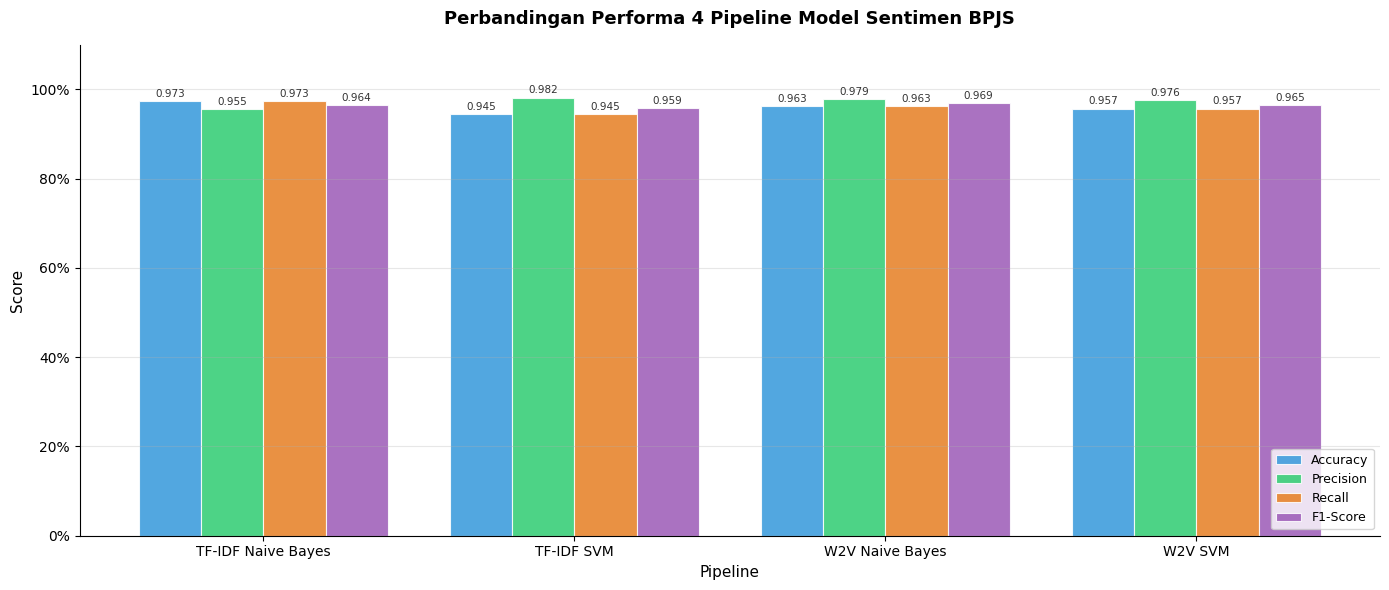

In [ ]:

# Perbandingan Model
results_clean = []
predictions_map = {
    "TF-IDF Naive Bayes" : (pred_A, "Pipeline A"),
    "TF-IDF SVM": (pred_B, "Pipeline B"),
    "W2V Naive Bayes"    : (pred_C, "Pipeline C"),
    "W2V SVM"   : (pred_D, "Pipeline D"),
}

for label, (pred, pipe_name) in predictions_map.items():
    results_clean.append({
        'Pipeline': label,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_test, pred, average='weighted', zero_division=0)
    })

compare_df = pd.DataFrame(results_clean)

# --- Grouped Bar Chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(compare_df))
width = 0.2
colors_met = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors_met)):
    bars = ax.bar(x + i * width, compare_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_title('Perbandingan Performa 4 Pipeline Model Sentimen BPJS',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=11)
ax.set_xlabel('Pipeline', fontsize=11)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(compare_df['Pipeline'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Peringkat Model Terbaik

In [ ]:
print("\nRanking Model berdasarkan F1-Score Weighted:")
ranking = compare_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
ranking.index += 1
display(ranking[['Pipeline', 'F1-Score', 'Accuracy', 'Precision', 'Recall']])


Ranking Model berdasarkan F1-Score Weighted:


,Pipeline,F1-Score,Accuracy,Precision,Recall
1,W2V Naive Bayes,0.969294,0.963039,0.978916,0.963039
2,W2V SVM,0.964537,0.956879,0.975502,0.956879
3,TF-IDF Naive Bayes,0.964191,0.973306,0.955245,0.973306
4,TF-IDF SVM,0.958961,0.944559,0.981869,0.944559


Grouped bar chart dipilih karena memungkinkan perbandingan **multi-metrik sekaligus**
untuk semua pipeline lebih informatif dibanding 4 bar chart terpisah.

Panduan Interpretasi

Model terbaik bukan hanya yang memiliki F1 tertinggi, tetapi juga yang memiliki:
- **Gap kecil antara train dan test performance** (indikator generalisasi baik)
- **Konsistensi Precision dan Recall** (tidak mengorbankan satu untuk yang lain secara ekstrem)
- **Performa stabil per kelas** (tidak hanya unggul di kelas mayoritas)

Ekspektasi Umum pada Dataset Skala Ini

Pada dataset ~700 baris dengan 3 kelas, ekspektasi performa yang realistis:
- F1-Score 0.70-0.80: Cukup baik, siap untuk pilot deployment dengan human review
- F1-Score 0.80-0.90: Baik, dapat digunakan untuk otomasi sebagian
- F1-Score > 0.90: Perlu dicurigai kemungkinan label terlalu simpel atau ada leakage

Jika semua model berada di bawah 0.65, problem ada di kualitas label, bukan di model
kembali ke Cell 12 untuk review dan perbaikan labeling.

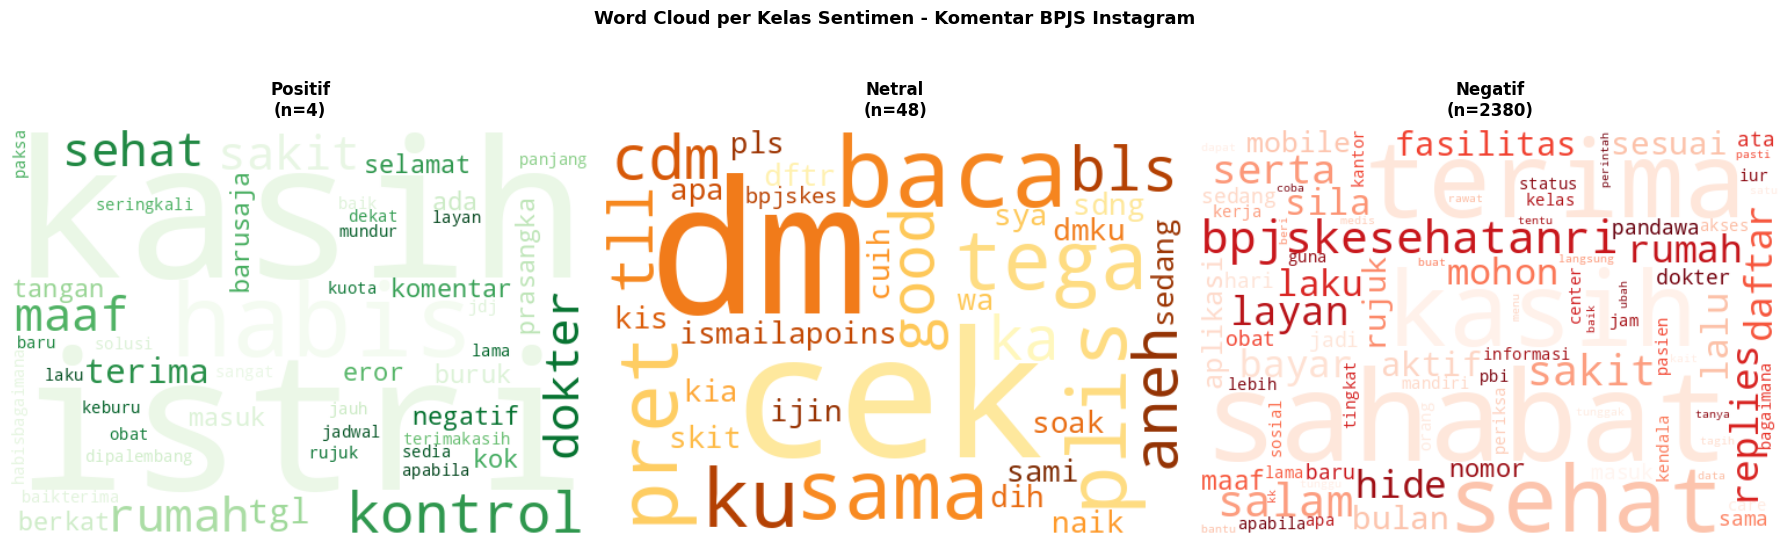

In [ ]:
# Insight - Word Cloud per Kelas Sentimen
sentimen_list = ['Positif', 'Netral', 'Negatif']
wc_colors = {'Positif': 'Greens', 'Netral': 'YlOrBr', 'Negatif': 'Reds'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Cloud per Kelas Sentimen - Komentar BPJS Instagram',
             fontsize=13, fontweight='bold', y=1.01)

for ax, sentimen in zip(axes, sentimen_list):
    subset = df_clean[df_clean['sentimen'] == sentimen]['teks_bersih']
    text_combined = ' '.join(subset)

    if not text_combined.strip():
        ax.text(0.5, 0.5, f'Tidak ada data\n{sentimen}',
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        continue

    wc = WordCloud(
        width=500,
        height=350,
        background_color='white',
        colormap=wc_colors[sentimen],
        max_words=100,
        collocations=False,
        random_state=RANDOM_STATE,
        min_font_size=8
    ).generate(text_combined)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(
        f'{sentimen}\n(n={len(subset)})',
        fontsize=12, fontweight='bold', pad=10
    )

plt.tight_layout()
plt.savefig('wordcloud_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()